# Tarea 1 Electivo IA

## 1. Generación del dataset sintético

Generación DataSet

*Para este ejercicio, debe generar un dataset sintético como el anterior que replique las características del entorno médico real. En el código de ejemplo, note que se generan datos 2D; en la práctica real se usan atributos elegidos “a mano” de acuerdo al conocimiento de expertos y la experiencia. Para este ejercicio, nos restringiremos a un conjunto de biomarcadores y factores de riesgo que permiten diferenciar los niveles de gravedad. Estos atributos han sido seleccionados para que el modelo tenga que lidiar con diferentes escalas, distribuciones y tipos de datos.*

Primeras 5 filas del dataset:
   Troponina_T  Presion_Arterial  Fibrilacion_V  Diabetes  Tipo_Dolor  \
0    10.173441        126.356313              0         0           1   
1    11.930764        113.607590              0         0           1   
2     0.636503        119.669821              0         0           1   
3     5.705352        118.338528              0         0           1   
4     3.501432        111.685138              0         0           1   

        Edad  Clase  
0  54.415251      0  
1  45.597284      0  
2  53.385941      0  
3  50.240863      0  
4  35.847303      0  

Cantidad de pacientes por clase:
Clase
0    800
1    150
2     50
Name: count, dtype: int64

Resumen estadístico de variables numéricas:
       Troponina_T  Presion_Arterial  Fibrilacion_V     Diabetes   Tipo_Dolor  \
count  1000.000000       1000.000000     1000.00000  1000.000000  1000.000000   
mean     16.739761        127.174951        0.06100     0.145000     1.839000   
std      26.552603

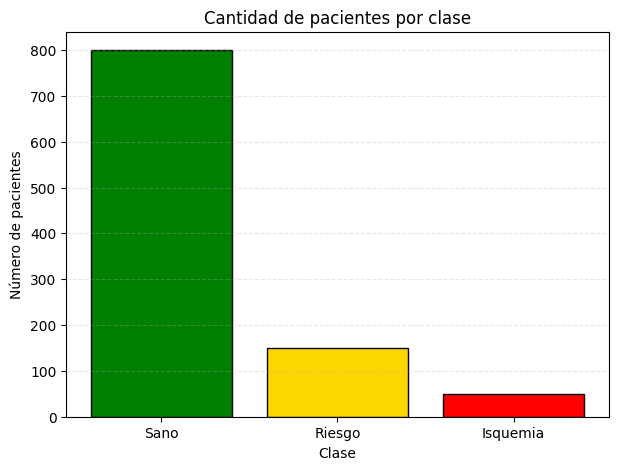

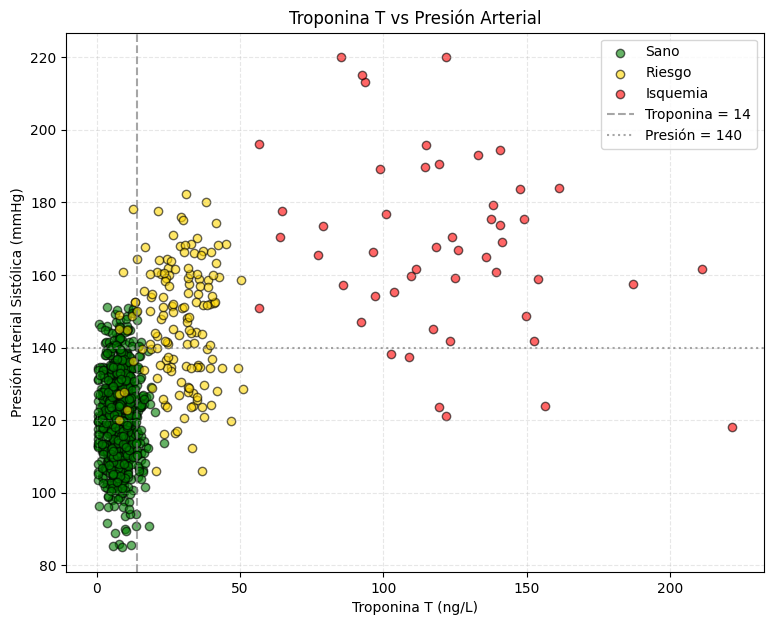

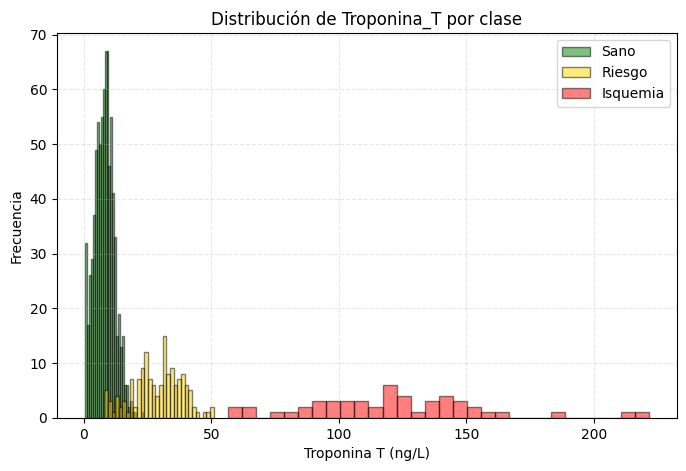

In [1]:
# -----------------------------
# 1. IMPORTAR LIBRERÍAS
# -----------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# -----------------------------
# 2. FIJAR SEMILLA
# -----------------------------
# Esto permite que los resultados sean reproducibles.
np.random.seed(42)


# -----------------------------
# 3. CANTIDAD DE PACIENTES POR CLASE
# -----------------------------
n_sano = 800
n_riesgo = 150
n_isquemia = 50

# -----------------------------
# 4. GENERAR DATOS PARA PACIENTES SANOS (CLASE 0)
# -----------------------------
# np.random.normal(media, desviación estándar, cantidad)
# genera valores aleatorios con distribución normal.

troponina_0 = np.random.normal(loc=8, scale=4, size=n_sano)
presion_0 = np.random.normal(loc=120, scale=12, size=n_sano)
edad_0 = np.random.normal(loc=45, scale=12, size=n_sano)

# np.random.binomial(1, probabilidad, cantidad)
# genera variables binarias: 0 o 1.
fibrilacion_0 = np.random.binomial(1, 0.01, n_sano)
diabetes_0 = np.random.binomial(1, 0.12, n_sano)

# np.random.choice(lista, size=cantidad, p=probabilidades)
# elige valores categóricos según probabilidades dadas.
tipo_dolor_0 = np.random.choice(
    [1, 2, 3, 4],
    size=n_sano,
    p=[0.60, 0.25, 0.10, 0.05]
)

# np.clip(valor, mínimo, máximo)
# sirve para limitar los datos a un rango razonable.
troponina_0 = np.clip(troponina_0, 0.5, 25)
presion_0 = np.clip(presion_0, 85, 170)
edad_0 = np.clip(edad_0, 18, 90)


# -----------------------------
# 5. GENERAR DATOS PARA PACIENTES DE RIESGO (CLASE 1)
# -----------------------------
troponina_1 = np.random.normal(loc=30, scale=10, size=n_riesgo)
presion_1 = np.random.normal(loc=145, scale=18, size=n_riesgo)
edad_1 = np.random.normal(loc=60, scale=10, size=n_riesgo)

fibrilacion_1 = np.random.binomial(1, 0.08, n_riesgo)
diabetes_1 = np.random.binomial(1, 0.30, n_riesgo)

tipo_dolor_1 = np.random.choice(
    [1, 2, 3, 4],
    size=n_riesgo,
    p=[0.15, 0.35, 0.30, 0.20]
)

troponina_1 = np.clip(troponina_1, 8, 70)
presion_1 = np.clip(presion_1, 90, 200)
edad_1 = np.clip(edad_1, 25, 95)


# -----------------------------
# 6. GENERAR DATOS PARA PACIENTES CON ISQUEMIA CRÍTICA (CLASE 2)
# -----------------------------
troponina_2 = np.random.normal(loc=120, scale=40, size=n_isquemia)
presion_2 = np.random.normal(loc=170, scale=25, size=n_isquemia)
edad_2 = np.random.normal(loc=70, scale=9, size=n_isquemia)

fibrilacion_2 = np.random.binomial(1, 0.75, n_isquemia)
diabetes_2 = np.random.binomial(1, 0.40, n_isquemia)

tipo_dolor_2 = np.random.choice(
    [1, 2, 3, 4],
    size=n_isquemia,
    p=[0.05, 0.10, 0.30, 0.55]
)

troponina_2 = np.clip(troponina_2, 40, 400)
presion_2 = np.clip(presion_2, 95, 220)
edad_2 = np.clip(edad_2, 35, 95)


# -----------------------------
# 7. CREAR DATAFRAMES POR CADA CLASE
# -----------------------------
# Un DataFrame es una tabla de datos con filas y columnas.

df_0 = pd.DataFrame({
    "Troponina_T": troponina_0,
    "Presion_Arterial": presion_0,
    "Fibrilacion_V": fibrilacion_0,
    "Diabetes": diabetes_0,
    "Tipo_Dolor": tipo_dolor_0,
    "Edad": edad_0,
    "Clase": 0
})

df_1 = pd.DataFrame({
    "Troponina_T": troponina_1,
    "Presion_Arterial": presion_1,
    "Fibrilacion_V": fibrilacion_1,
    "Diabetes": diabetes_1,
    "Tipo_Dolor": tipo_dolor_1,
    "Edad": edad_1,
    "Clase": 1
})

df_2 = pd.DataFrame({
    "Troponina_T": troponina_2,
    "Presion_Arterial": presion_2,
    "Fibrilacion_V": fibrilacion_2,
    "Diabetes": diabetes_2,
    "Tipo_Dolor": tipo_dolor_2,
    "Edad": edad_2,
    "Clase": 2
})


# -----------------------------
# 8. UNIR TODOS LOS PACIENTES EN UN SOLO DATAFRAME
# -----------------------------
df = pd.concat([df_0, df_1, df_2], ignore_index=True)

# Mezclar las filas para que no queden ordenadas por clase
df = df.sample(frac=1, random_state=42).reset_index(drop=True)


# -----------------------------
# 9. REVISAR EL DATASET
# -----------------------------
print("Primeras 5 filas del dataset:")
print(df.head())

print("\nCantidad de pacientes por clase:")
print(df["Clase"].value_counts().sort_index())

print("\nResumen estadístico de variables numéricas:")
print(df.describe())


# -----------------------------
# 10. GRÁFICO 1: CANTIDAD DE PACIENTES POR CLASE
# -----------------------------
plt.figure(figsize=(7, 5))

conteo = df["Clase"].value_counts().sort_index()

plt.bar(
    ["Sano", "Riesgo", "Isquemia"],
    conteo.values,
    color=["green", "gold", "red"],
    edgecolor="black"
)

plt.title("Cantidad de pacientes por clase")
plt.xlabel("Clase")
plt.ylabel("Número de pacientes")
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.show()


# -----------------------------
# 11. GRÁFICO 2: TROPONINA VS PRESIÓN
# -----------------------------
plt.figure(figsize=(9, 7))

# Clase 0
plt.scatter(
    df[df["Clase"] == 0]["Troponina_T"],
    df[df["Clase"] == 0]["Presion_Arterial"],
    c="green",
    label="Sano",
    edgecolors="black",
    alpha=0.6
)

# Clase 1
plt.scatter(
    df[df["Clase"] == 1]["Troponina_T"],
    df[df["Clase"] == 1]["Presion_Arterial"],
    c="gold",
    label="Riesgo",
    edgecolors="black",
    alpha=0.6
)

# Clase 2
plt.scatter(
    df[df["Clase"] == 2]["Troponina_T"],
    df[df["Clase"] == 2]["Presion_Arterial"],
    c="red",
    label="Isquemia",
    edgecolors="black",
    alpha=0.6
)

# Líneas de referencia clínicas
plt.axvline(x=14, color="gray", linestyle="--", alpha=0.7, label="Troponina = 14")
plt.axhline(y=140, color="gray", linestyle=":", alpha=0.7, label="Presión = 140")

plt.title("Troponina T vs Presión Arterial")
plt.xlabel("Troponina T (ng/L)")
plt.ylabel("Presión Arterial Sistólica (mmHg)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()


# -----------------------------
# 12. GRÁFICO 3: HISTOGRAMA DE TROponina
# -----------------------------
plt.figure(figsize=(8, 5))

plt.hist(df[df["Clase"] == 0]["Troponina_T"], bins=30, alpha=0.5, label="Sano", color="green", edgecolor="black")
plt.hist(df[df["Clase"] == 1]["Troponina_T"], bins=30, alpha=0.5, label="Riesgo", color="gold", edgecolor="black")
plt.hist(df[df["Clase"] == 2]["Troponina_T"], bins=30, alpha=0.5, label="Isquemia", color="red", edgecolor="black")

plt.title("Distribución de Troponina_T por clase")
plt.xlabel("Troponina T (ng/L)")
plt.ylabel("Frecuencia")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()


## 2. Preparación y preprocesamiento de los datos

# Parte 2
Preparando datos para el modelo

In [2]:
# ==========================================================
# PREPARACIÓN DE LOS DATOS PARA EL MODELO
# ==========================================================

# train_test_split:
# separa los datos en entrenamiento y prueba
from sklearn.model_selection import train_test_split

# 1. Separar variables predictoras (X) y variable objetivo (y)
X = df.drop(columns=["Clase"])
y = df["Clase"].values

# 2. Dividir en entrenamiento y prueba
# stratify=y mantiene la proporción de clases en ambos conjuntos
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Forma de X_train:", X_train.shape)
print("Forma de X_test:", X_test.shape)

Forma de X_train: (800, 6)
Forma de X_test: (200, 6)


Aplicamos ONE-HOT Econcodig

In [3]:
# ==========================================================
# ONE-HOT ENCODING DE LA VARIABLE CATEGÓRICA
# ==========================================================

# Convertimos la variable Tipo_Dolor en columnas binarias
X_train = pd.get_dummies(X_train, columns=["Tipo_Dolor"], prefix="Dolor")
X_test = pd.get_dummies(X_test, columns=["Tipo_Dolor"], prefix="Dolor")

# Asegurar que train y test tengan las mismas columnas
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

print("Columnas después del One-Hot Encoding:")
print(X_train.columns.tolist())

Columnas después del One-Hot Encoding:
['Troponina_T', 'Presion_Arterial', 'Fibrilacion_V', 'Diabetes', 'Edad', 'Dolor_1', 'Dolor_2', 'Dolor_3', 'Dolor_4']


Escalamos variables continuas

In [4]:
# ==========================================================
# ESCALAMIENTO DE VARIABLES CONTINUAS
# ==========================================================

# Variables continuas que sí conviene escalar
columnas_continuas = ["Troponina_T", "Presion_Arterial", "Edad"]

# Calcular media y desviación estándar SOLO con train
medias_train = X_train[columnas_continuas].mean()
stds_train = X_train[columnas_continuas].std()

# Estandarizar: (x - media) / desviación estándar
X_train[columnas_continuas] = (X_train[columnas_continuas] - medias_train) / stds_train
X_test[columnas_continuas] = (X_test[columnas_continuas] - medias_train) / stds_train

# Convertir a arreglos numpy
X_train_np = X_train.values.astype(float)
X_test_np = X_test.values.astype(float)

print("Forma final de X_train_np:", X_train_np.shape)
print("Forma final de X_test_np:", X_test_np.shape)

Forma final de X_train_np: (800, 9)
Forma final de X_test_np: (200, 9)


## 3. Implementación de modelos scratch

Implementación de la clase desde cero

In [5]:
# ==========================================================
# REGRESIÓN LOGÍSTICA MULTICLASE DESDE CERO
# ==========================================================

class LogisticRegressionScratch:
    """
    Regresión logística multiclase usando softmax y descenso de gradiente.
    Permite regularización:
    - None   : sin regularización
    - 'l1'   : Lasso
    - 'l2'   : Ridge
    - 'elastic' : Elastic Net
    """

    def __init__(self, learning_rate=0.05, epochs=3000, penalty=None,
                 lambda_reg=0.01, l1_ratio=0.5, verbose=False):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.penalty = penalty
        self.lambda_reg = lambda_reg
        self.l1_ratio = l1_ratio
        self.verbose = verbose

        self.W = None
        self.loss_history = []
        self.n_classes = None

    def _add_bias(self, X):
        """
        Agrega una columna de 1 al inicio para representar el intercepto.
        """
        return np.c_[np.ones((X.shape[0], 1)), X]

    def _one_hot(self, y, n_classes):
        """
        Convierte el vector de clases en matriz one-hot.
        Ejemplo:
        y = [0,2,1]
        -->
        [[1,0,0],
         [0,0,1],
         [0,1,0]]
        """
        Y = np.zeros((len(y), n_classes))
        Y[np.arange(len(y)), y] = 1
        return Y

    def _softmax(self, Z):
        """
        Calcula softmax fila por fila.
        Se resta el máximo por estabilidad numérica.
        """
        Z = Z - np.max(Z, axis=1, keepdims=True)
        exp_Z = np.exp(Z)
        return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)

    def _regularization_loss(self):
        """
        Calcula el valor de la penalización.
        No se penaliza la fila del bias.
        """
        W_no_bias = self.W[1:, :]

        if self.penalty is None:
            return 0.0

        elif self.penalty == "l1":
            return self.lambda_reg * np.sum(np.abs(W_no_bias))

        elif self.penalty == "l2":
            return (self.lambda_reg / 2.0) * np.sum(W_no_bias ** 2)

        elif self.penalty == "elastic":
            l1_part = self.l1_ratio * np.sum(np.abs(W_no_bias))
            l2_part = ((1 - self.l1_ratio) / 2.0) * np.sum(W_no_bias ** 2)
            return self.lambda_reg * (l1_part + l2_part)

        else:
            raise ValueError("Penalización no válida")

    def _regularization_gradient(self):
        """
        Calcula el gradiente de la regularización.
        """
        grad_reg = np.zeros_like(self.W)
        W_no_bias = self.W[1:, :]

        if self.penalty is None:
            return grad_reg

        elif self.penalty == "l1":
            grad_reg[1:, :] = self.lambda_reg * np.sign(W_no_bias)

        elif self.penalty == "l2":
            grad_reg[1:, :] = self.lambda_reg * W_no_bias

        elif self.penalty == "elastic":
            grad_reg[1:, :] = self.lambda_reg * (
                self.l1_ratio * np.sign(W_no_bias) +
                (1 - self.l1_ratio) * W_no_bias
            )

        else:
            raise ValueError("Penalización no válida")

        return grad_reg

    def fit(self, X, y):
        """
        Entrena el modelo con descenso de gradiente.
        """
        Xb = self._add_bias(X)

        n_samples, n_features = Xb.shape
        self.n_classes = len(np.unique(y))

        # Inicializar pesos en cero
        self.W = np.zeros((n_features, self.n_classes))

        # Convertir etiquetas a one-hot
        Y = self._one_hot(y, self.n_classes)

        for epoch in range(self.epochs):
            # 1. Puntajes lineales
            logits = Xb @ self.W

            # 2. Probabilidades
            probs = self._softmax(logits)

            # 3. Pérdida de entropía cruzada
            eps = 1e-12
            ce_loss = -np.mean(np.sum(Y * np.log(probs + eps), axis=1))

            # 4. Agregar regularización
            reg_loss = self._regularization_loss()
            loss_total = ce_loss + reg_loss
            self.loss_history.append(loss_total)

            # 5. Gradiente de la parte de datos
            grad_data = (Xb.T @ (probs - Y)) / n_samples

            # 6. Gradiente de regularización
            grad_reg = self._regularization_gradient()

            # 7. Gradiente total
            grad_total = grad_data + grad_reg

            # 8. Actualización de pesos
            self.W -= self.learning_rate * grad_total

            if self.verbose and epoch % 500 == 0:
                print(f"Época {epoch}: loss = {loss_total:.4f}")

    def predict_proba(self, X):
        """
        Devuelve probabilidades por clase.
        """
        Xb = self._add_bias(X)
        logits = Xb @ self.W
        return self._softmax(logits)

    def predict(self, X):
        """
        Devuelve la clase con mayor probabilidadsigamos.
        """
        probs = self.predict_proba(X)
        return np.argmax(probs, axis=1)

Entrenamiento de modelos scratch

In [6]:
# ==========================================================
# ENTRENAR LOS 4 MODELOS DESDE CERO
# ==========================================================

# Diccionario para guardar los modelos entrenados
modelos_scratch = {}

# -----------------------------
# 1. Regresión logística sin regularización
# -----------------------------
modelo_reglog = LogisticRegressionScratch(
    learning_rate=0.05,   # tamaño del paso en cada actualización
    epochs=3000,          # cantidad de iteraciones
    penalty=None,         # sin regularización
    verbose=False
)

print("Entrenando RegLog...")
modelo_reglog.fit(X_train_np, y_train)
modelos_scratch["RegLog"] = modelo_reglog


# -----------------------------
# 2. Regresión logística con L1
# -----------------------------
modelo_reglog_l1 = LogisticRegressionScratch(
    learning_rate=0.05,
    epochs=3000,
    penalty="l1",         # regularización Lasso
    lambda_reg=0.01,      # fuerza de la regularización
    verbose=False
)

print("Entrenando RegLog-L1...")
modelo_reglog_l1.fit(X_train_np, y_train)
modelos_scratch["RegLog-L1"] = modelo_reglog_l1


# -----------------------------
# 3. Regresión logística con L2
# -----------------------------
modelo_reglog_l2 = LogisticRegressionScratch(
    learning_rate=0.05,
    epochs=3000,
    penalty="l2",         # regularización Ridge
    lambda_reg=0.01,
    verbose=False
)

print("Entrenando RegLog-L2...")
modelo_reglog_l2.fit(X_train_np, y_train)
modelos_scratch["RegLog-L2"] = modelo_reglog_l2


# -----------------------------
# 4. Regresión logística con Elastic Net
# -----------------------------
modelo_reglog_elastic = LogisticRegressionScratch(
    learning_rate=0.05,
    epochs=3000,
    penalty="elastic",    # mezcla entre L1 y L2
    lambda_reg=0.01,
    l1_ratio=0.5,         # 50% L1 y 50% L2
    verbose=False
)

print("Entrenando RegLog-L1-L2...")
modelo_reglog_elastic.fit(X_train_np, y_train)
modelos_scratch["RegLog-L1-L2"] = modelo_reglog_elastic


print("Entrenamiento de modelos scratch finalizado.")

Entrenando RegLog...
Entrenando RegLog-L1...
Entrenando RegLog-L2...
Entrenando RegLog-L1-L2...
Entrenamiento de modelos scratch finalizado.


Antes de pasar a sklearn, conviene hacer una verificación simple:

ver si cada modelo guardó valores de pérdida,
revisar el último valor de la loss.

In [7]:
# ==========================================================
# REVISAR PÉRDIDA FINAL DE CADA MODELO SCRATCH
# ==========================================================

for nombre, modelo in modelos_scratch.items():
    print(f"{nombre} -> última loss: {modelo.loss_history[-1]:.4f}")

RegLog -> última loss: 0.0854
RegLog-L1 -> última loss: 0.1960
RegLog-L2 -> última loss: 0.1748
RegLog-L1-L2 -> última loss: 0.1941


**Función para evaluar un modelo**

Esta función sirve para no repetir código cuatro veces.

In [8]:
# ==========================================================
# IMPORTAR MÉTRICAS PARA EVALUACIÓN
# ==========================================================

from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix
import seaborn as sns

# ==========================================================
# FUNCIÓN DE EVALUACIÓN
# ==========================================================

def evaluar_modelo(nombre_modelo, modelo, X_test, y_test):
    """
    Evalúa un modelo ya entrenado usando:
    - accuracy
    - balanced accuracy
    - classification report
    - matriz de confusión
    """

    # 1. Predecir clases
    y_pred = modelo.predict(X_test)

    # 2. Calcular métricas principales
    acc = accuracy_score(y_test, y_pred)
    bal_acc = balanced_accuracy_score(y_test, y_pred)

    print("\n" + "=" * 60)
    print(f"Modelo: {nombre_modelo}")
    print("=" * 60)
    print(f"Accuracy: {acc:.4f}")
    print(f"Balanced Accuracy: {bal_acc:.4f}")

    # 3. Reporte detallado por clase
    print("\nReporte de clasificación:")
    print(classification_report(
        y_test,
        y_pred,
        target_names=["Sano", "Riesgo", "Isquemia"],
        digits=4
    ))

    # 4. Matriz de confusión
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Sano", "Riesgo", "Isquemia"],
        yticklabels=["Sano", "Riesgo", "Isquemia"]
    )
    plt.title(f"Matriz de confusión - {nombre_modelo}")
    plt.xlabel("Predicción")
    plt.ylabel("Valor real")
    plt.show()

    # 5. Devolver resultados para guardarlos después
    return {
        "Modelo": nombre_modelo,
        "Accuracy": acc,
        "Balanced_Accuracy": bal_acc
    }

Evaluacion de los modelos con la funcion creada.


Modelo: RegLog
Accuracy: 0.9750
Balanced Accuracy: 0.9313

Reporte de clasificación:
              precision    recall  f1-score   support

        Sano     0.9815    0.9938    0.9876       160
      Riesgo     0.9310    0.9000    0.9153        30
    Isquemia     1.0000    0.9000    0.9474        10

    accuracy                         0.9750       200
   macro avg     0.9708    0.9313    0.9501       200
weighted avg     0.9748    0.9750    0.9747       200



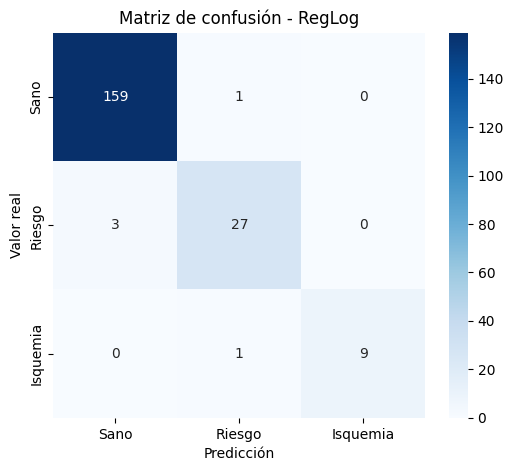


Modelo: RegLog-L1
Accuracy: 0.9600
Balanced Accuracy: 0.8979

Reporte de clasificación:
              precision    recall  f1-score   support

        Sano     0.9636    0.9938    0.9785       160
      Riesgo     0.9231    0.8000    0.8571        30
    Isquemia     1.0000    0.9000    0.9474        10

    accuracy                         0.9600       200
   macro avg     0.9622    0.8979    0.9277       200
weighted avg     0.9594    0.9600    0.9587       200



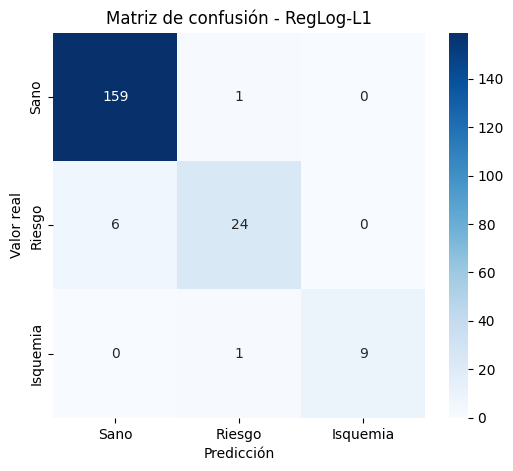


Modelo: RegLog-L2
Accuracy: 0.9500
Balanced Accuracy: 0.8757

Reporte de clasificación:
              precision    recall  f1-score   support

        Sano     0.9521    0.9938    0.9725       160
      Riesgo     0.9167    0.7333    0.8148        30
    Isquemia     1.0000    0.9000    0.9474        10

    accuracy                         0.9500       200
   macro avg     0.9563    0.8757    0.9116       200
weighted avg     0.9492    0.9500    0.9476       200



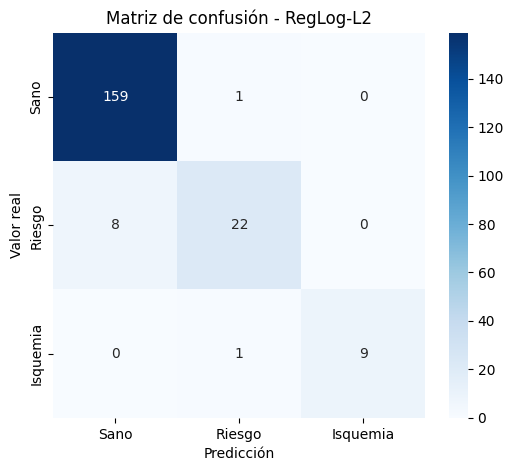


Modelo: RegLog-L1-L2
Accuracy: 0.9500
Balanced Accuracy: 0.8757

Reporte de clasificación:
              precision    recall  f1-score   support

        Sano     0.9521    0.9938    0.9725       160
      Riesgo     0.9167    0.7333    0.8148        30
    Isquemia     1.0000    0.9000    0.9474        10

    accuracy                         0.9500       200
   macro avg     0.9563    0.8757    0.9116       200
weighted avg     0.9492    0.9500    0.9476       200



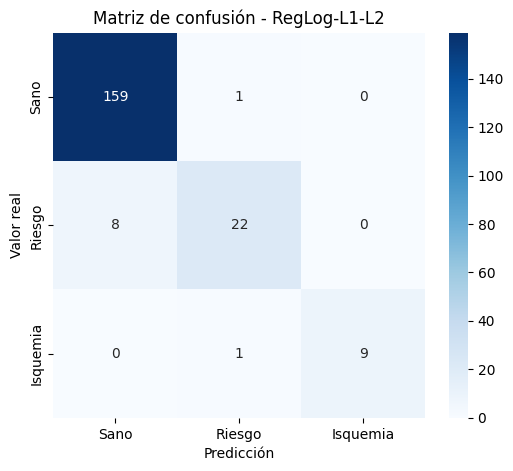

In [9]:
# ==========================================================
# EVALUAR LOS 4 MODELOS SCRATCH
# ==========================================================

resultados_scratch = []

for nombre, modelo in modelos_scratch.items():
    resultado = evaluar_modelo(nombre, modelo, X_test_np, y_test)
    resultados_scratch.append(resultado)

Bloques con modelos de referencia y comparaciones.

In [10]:
# ==========================================================
# RESUMEN DE RESULTADOS SCRATCH
# ==========================================================

df_resultados_scratch = pd.DataFrame(resultados_scratch)

print("\nResumen de resultados de modelos scratch:")
print(df_resultados_scratch.sort_values(by="Balanced_Accuracy", ascending=False))


Resumen de resultados de modelos scratch:
         Modelo  Accuracy  Balanced_Accuracy
0        RegLog     0.975           0.931250
1     RegLog-L1     0.960           0.897917
2     RegLog-L2     0.950           0.875694
3  RegLog-L1-L2     0.950           0.875694


## 4. Modelos de referencia con scikit-learn

Entranamiento 4 modelos de **referencia**

In [11]:
# ==========================================================
# IMPORTAR MODELO DE REFERENCIA
# ==========================================================

from sklearn.linear_model import LogisticRegression

In [12]:
# ==========================================================
# ENTRENAR LOS 4 MODELOS DE REFERENCIA (SCIKIT-LEARN)
# ==========================================================

modelos_sk = {}

# -----------------------------
# 1. Regresión logística sin regularización
# -----------------------------
modelo_reglog_sk = LogisticRegression(
    penalty=None,
    solver="lbfgs",
    multi_class="multinomial",
    max_iter=5000,
    random_state=42
)

print("Entrenando RegLog-sk...")
modelo_reglog_sk.fit(X_train_np, y_train)
modelos_sk["RegLog-sk"] = modelo_reglog_sk


# -----------------------------
# 2. Regresión logística con L1
# -----------------------------
modelo_reglog_l1_sk = LogisticRegression(
    penalty="l1",
    solver="saga",
    multi_class="multinomial",
    max_iter=5000,
    C=100.0,
    random_state=42
)

print("Entrenando RegLog-L1-sk...")
modelo_reglog_l1_sk.fit(X_train_np, y_train)
modelos_sk["RegLog-L1-sk"] = modelo_reglog_l1_sk


# -----------------------------
# 3. Regresión logística con L2
# -----------------------------
modelo_reglog_l2_sk = LogisticRegression(
    penalty="l2",
    solver="lbfgs",
    multi_class="multinomial",
    max_iter=5000,
    C=100.0,
    random_state=42
)

print("Entrenando RegLog-L2-sk...")
modelo_reglog_l2_sk.fit(X_train_np, y_train)
modelos_sk["RegLog-L2-sk"] = modelo_reglog_l2_sk


# -----------------------------
# 4. Regresión logística con Elastic Net
# -----------------------------
modelo_reglog_elastic_sk = LogisticRegression(
    penalty="elasticnet",
    solver="saga",
    multi_class="multinomial",
    max_iter=5000,
    C=100.0,
    l1_ratio=0.5,
    random_state=42
)

print("Entrenando RegLog-L1-L2-sk...")
modelo_reglog_elastic_sk.fit(X_train_np, y_train)
modelos_sk["RegLog-L1-L2-sk"] = modelo_reglog_elastic_sk


print("Entrenamiento de modelos sklearn finalizado.")

Entrenando RegLog-sk...
Entrenando RegLog-L1-sk...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Entrenando RegLog-L2-sk...
Entrenando RegLog-L1-L2-sk...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Entrenamiento de modelos sklearn finalizado.


Evaluacion de los 4 modelos **SKLEARN**


Modelo: RegLog-sk
Accuracy: 0.9800
Balanced Accuracy: 0.9424

Reporte de clasificación:
              precision    recall  f1-score   support

        Sano     0.9876    0.9938    0.9907       160
      Riesgo     0.9333    0.9333    0.9333        30
    Isquemia     1.0000    0.9000    0.9474        10

    accuracy                         0.9800       200
   macro avg     0.9736    0.9424    0.9571       200
weighted avg     0.9801    0.9800    0.9799       200



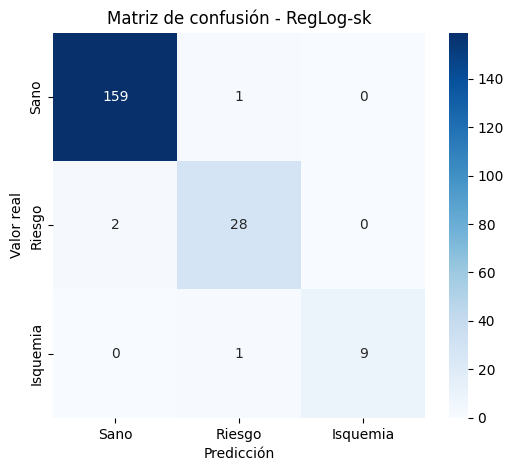


Modelo: RegLog-L1-sk
Accuracy: 0.9800
Balanced Accuracy: 0.9424

Reporte de clasificación:
              precision    recall  f1-score   support

        Sano     0.9876    0.9938    0.9907       160
      Riesgo     0.9333    0.9333    0.9333        30
    Isquemia     1.0000    0.9000    0.9474        10

    accuracy                         0.9800       200
   macro avg     0.9736    0.9424    0.9571       200
weighted avg     0.9801    0.9800    0.9799       200



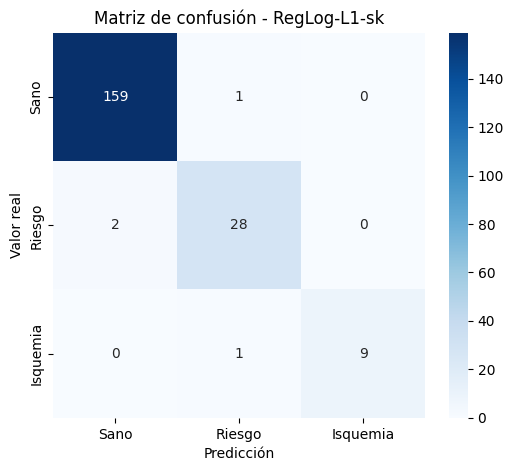


Modelo: RegLog-L2-sk
Accuracy: 0.9800
Balanced Accuracy: 0.9424

Reporte de clasificación:
              precision    recall  f1-score   support

        Sano     0.9876    0.9938    0.9907       160
      Riesgo     0.9333    0.9333    0.9333        30
    Isquemia     1.0000    0.9000    0.9474        10

    accuracy                         0.9800       200
   macro avg     0.9736    0.9424    0.9571       200
weighted avg     0.9801    0.9800    0.9799       200



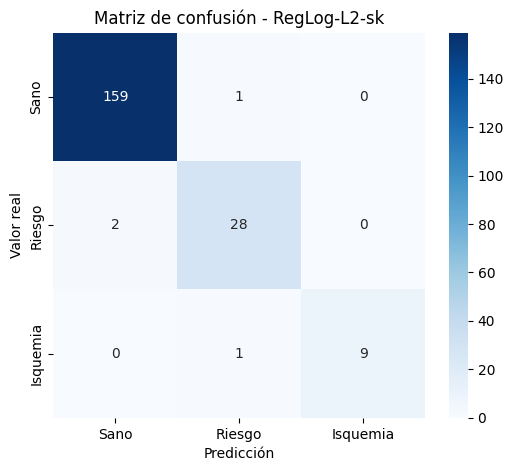


Modelo: RegLog-L1-L2-sk
Accuracy: 0.9800
Balanced Accuracy: 0.9424

Reporte de clasificación:
              precision    recall  f1-score   support

        Sano     0.9876    0.9938    0.9907       160
      Riesgo     0.9333    0.9333    0.9333        30
    Isquemia     1.0000    0.9000    0.9474        10

    accuracy                         0.9800       200
   macro avg     0.9736    0.9424    0.9571       200
weighted avg     0.9801    0.9800    0.9799       200



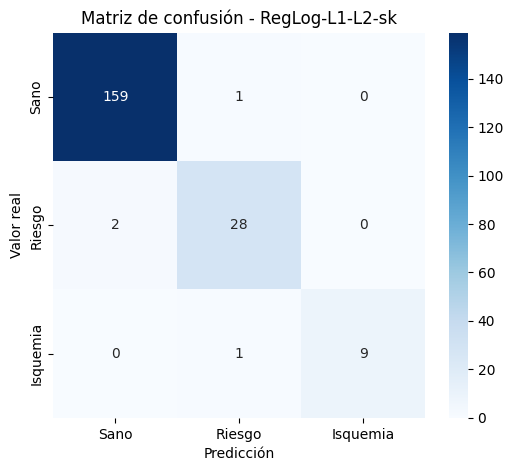

In [13]:
# ==========================================================
# EVALUAR LOS 4 MODELOS DE SCIKIT-LEARN
# ==========================================================

resultados_sk = []

for nombre, modelo in modelos_sk.items():
    resultado = evaluar_modelo(nombre, modelo, X_test_np, y_test)
    resultados_sk.append(resultado)

**Resumen de Resultados SKLEARN**

In [14]:
# ==========================================================
# RESUMEN DE RESULTADOS SKLEARN
# ==========================================================

df_resultados_sk = pd.DataFrame(resultados_sk)

print("\nResumen de resultados de modelos sklearn:")
print(df_resultados_sk.sort_values(by="Balanced_Accuracy", ascending=False))


Resumen de resultados de modelos sklearn:
            Modelo  Accuracy  Balanced_Accuracy
0        RegLog-sk      0.98           0.942361
1     RegLog-L1-sk      0.98           0.942361
2     RegLog-L2-sk      0.98           0.942361
3  RegLog-L1-L2-sk      0.98           0.942361


Resultados scratch vs sklearn

In [15]:
# ==========================================================
# COMPARACIÓN FINAL: SCRATCH VS SKLEARN
# ==========================================================

df_comparacion = pd.concat([df_resultados_scratch, df_resultados_sk], ignore_index=True)

print("\nComparación general de todos los modelos:")
print(df_comparacion.sort_values(by="Balanced_Accuracy", ascending=False))


Comparación general de todos los modelos:
            Modelo  Accuracy  Balanced_Accuracy
7  RegLog-L1-L2-sk     0.980           0.942361
6     RegLog-L2-sk     0.980           0.942361
5     RegLog-L1-sk     0.980           0.942361
4        RegLog-sk     0.980           0.942361
0           RegLog     0.975           0.931250
1        RegLog-L1     0.960           0.897917
3     RegLog-L1-L2     0.950           0.875694
2        RegLog-L2     0.950           0.875694


Gráfico comparativo de Balanced Accuracy

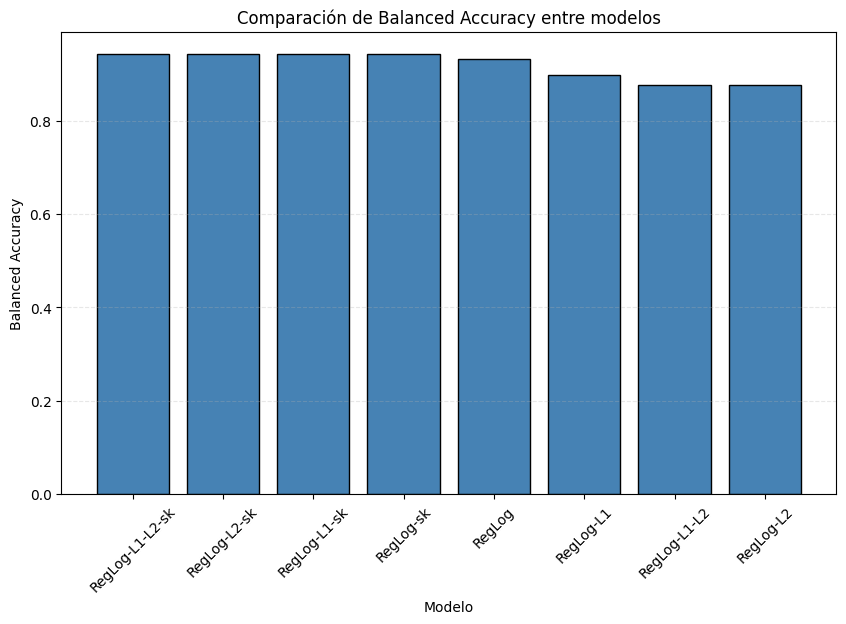

In [16]:
# ==========================================================
# GRÁFICO COMPARATIVO DE BALANCED ACCURACY
# ==========================================================

df_ordenado = df_comparacion.sort_values(by="Balanced_Accuracy", ascending=False)

plt.figure(figsize=(10, 6))
plt.bar(df_ordenado["Modelo"], df_ordenado["Balanced_Accuracy"], color="steelblue", edgecolor="black")
plt.title("Comparación de Balanced Accuracy entre modelos")
plt.xlabel("Modelo")
plt.ylabel("Balanced Accuracy")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.show()

## 5. Validación y métricas de desempeño

2. Validación, robustez y sensibilidad de los modelos En esta actividad se pide analizar el desempeño de los modelos implementados (1-8). El objetivo no es solo ajustar parámetros, sino evaluar la utilidad de las predicciones en un entorno crítico como el planteado. Para ello, aborde los siguientes ejes:

elección de métricas de desempeño: Justifique y aplique métricas que capturen el impacto real del desbalance de clases y la gravedad de los errores. Es obligatorio reportar:

**Recall (sensibilidad) por clase: Con especial énfasis en la detección de la clase isquemia crítica.**

**F1-Score ponderado (weighted): Para equilibrar precisión y sensibilidad en un contexto multiclase desbalanceado. **

In [17]:
# ==========================================================
# MÉTRICAS: RECALL POR CLASE Y F1 WEIGHTED
# ==========================================================

from sklearn.metrics import recall_score, f1_score

def calcular_metricas_base(modelo, X_test, y_test):
    """
    Calcula métricas base:
    - recall por clase
    - f1-score weighted
    """
    y_pred = modelo.predict(X_test)

    # Recall por clase (una posición por clase: 0, 1, 2)
    recall_por_clase = recall_score(y_test, y_pred, average=None, labels=[0, 1, 2])

    # F1-score ponderado
    f1_weighted = f1_score(y_test, y_pred, average="weighted")

    return {
        "recall_sano": recall_por_clase[0],
        "recall_riesgo": recall_por_clase[1],
        "recall_isquemia": recall_por_clase[2],
        "f1_weighted": f1_weighted
    }

F1-Score ponderado (weighted): Para equilibrar precisión y sensibilidad en un contexto multiclase desbalanceado.

In [18]:
# ==========================================================
# FUNCIÓN DE COSTO ASIMÉTRICA
# ==========================================================

def costo_total_asimetrico(y_true, y_pred, matriz_costos):
    """
    Calcula el costo total acumulado según una matriz de costos.

    matriz_costos[i, j] = costo de predecir j cuando la clase real es i
    """
    costo_total = 0

    for real, pred in zip(y_true, y_pred):
        costo_total += matriz_costos[real, pred]

    return costo_total


# Matriz de costos propuesta
matriz_costos = np.array([
    [0, 1, 4],   # real = sano
    [2, 0, 6],   # real = riesgo
    [10, 5, 0]   # real = isquemia crítica
])

Función de costo total: Diseñe y aplique una métrica de costo asimétrica donde se penalice con mayor severidad un falso negativo en la clase crítica que un falso positivo en la clase sana.

Matriz de confusión: Para visualizar los flujos de error entre categorías.

In [19]:
# ==========================================================
# EVALUACIÓN EXTENDIDA DE MODELOS
# ==========================================================

def evaluar_modelo_extendido(nombre_modelo, modelo, X_test, y_test, matriz_costos):
    """
    Evalúa un modelo usando métricas relevantes para el problema clínico.
    """
    y_pred = modelo.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    bal_acc = balanced_accuracy_score(y_test, y_pred)

    metricas_base = calcular_metricas_base(modelo, X_test, y_test)
    costo_total = costo_total_asimetrico(y_test, y_pred, matriz_costos)

    print("\n" + "=" * 70)
    print(f"Modelo: {nombre_modelo}")
    print("=" * 70)
    print(f"Accuracy: {acc:.4f}")
    print(f"Balanced Accuracy: {bal_acc:.4f}")
    print(f"Recall Sano: {metricas_base['recall_sano']:.4f}")
    print(f"Recall Riesgo: {metricas_base['recall_riesgo']:.4f}")
    print(f"Recall Isquemia: {metricas_base['recall_isquemia']:.4f}")
    print(f"F1 Weighted: {metricas_base['f1_weighted']:.4f}")
    print(f"Costo Total Asimétrico: {costo_total}")

    return {
        "Modelo": nombre_modelo,
        "Accuracy": acc,
        "Balanced_Accuracy": bal_acc,
        "Recall_Sano": metricas_base["recall_sano"],
        "Recall_Riesgo": metricas_base["recall_riesgo"],
        "Recall_Isquemia": metricas_base["recall_isquemia"],
        "F1_Weighted": metricas_base["f1_weighted"],
        "Costo_Total": costo_total
    }

Aplicando a los 8 modelos

In [20]:
# ==========================================================
# APLICAR EVALUACIÓN EXTENDIDA A LOS 8 MODELOS
# ==========================================================

resultados_extendidos = []

# Modelos scratch
for nombre, modelo in modelos_scratch.items():
    res = evaluar_modelo_extendido(nombre, modelo, X_test_np, y_test, matriz_costos)
    resultados_extendidos.append(res)

# Modelos sklearn
for nombre, modelo in modelos_sk.items():
    res = evaluar_modelo_extendido(nombre, modelo, X_test_np, y_test, matriz_costos)
    resultados_extendidos.append(res)

df_resultados_extendidos = pd.DataFrame(resultados_extendidos)

print("\nTabla resumen de métricas extendidas:")
print(df_resultados_extendidos.sort_values(by=["Recall_Isquemia", "Balanced_Accuracy"], ascending=[False, False]))


Modelo: RegLog
Accuracy: 0.9750
Balanced Accuracy: 0.9313
Recall Sano: 0.9938
Recall Riesgo: 0.9000
Recall Isquemia: 0.9000
F1 Weighted: 0.9747
Costo Total Asimétrico: 12

Modelo: RegLog-L1
Accuracy: 0.9600
Balanced Accuracy: 0.8979
Recall Sano: 0.9938
Recall Riesgo: 0.8000
Recall Isquemia: 0.9000
F1 Weighted: 0.9587
Costo Total Asimétrico: 18

Modelo: RegLog-L2
Accuracy: 0.9500
Balanced Accuracy: 0.8757
Recall Sano: 0.9938
Recall Riesgo: 0.7333
Recall Isquemia: 0.9000
F1 Weighted: 0.9476
Costo Total Asimétrico: 22

Modelo: RegLog-L1-L2
Accuracy: 0.9500
Balanced Accuracy: 0.8757
Recall Sano: 0.9938
Recall Riesgo: 0.7333
Recall Isquemia: 0.9000
F1 Weighted: 0.9476
Costo Total Asimétrico: 22

Modelo: RegLog-sk
Accuracy: 0.9800
Balanced Accuracy: 0.9424
Recall Sano: 0.9938
Recall Riesgo: 0.9333
Recall Isquemia: 0.9000
F1 Weighted: 0.9799
Costo Total Asimétrico: 10

Modelo: RegLog-L1-sk
Accuracy: 0.9800
Balanced Accuracy: 0.9424
Recall Sano: 0.9938
Recall Riesgo: 0.9333
Recall Isquemia: 0

In [21]:
# ==========================================================
# PRUEBA RÁPIDA DE DISTINTOS VALORES DE C EN SKLEARN
# ==========================================================

valores_C = [10, 1, 0.1, 0.01]

resultados_C = []

for C_val in valores_C:
    print(f"\nProbando modelos sklearn con C = {C_val}")

    # -----------------------------
    # Modelo L1
    # -----------------------------
    modelo_l1 = LogisticRegression(
        penalty="l1",
        solver="saga",
        multi_class="multinomial",
        max_iter=5000,
        C=C_val,
        random_state=42
    )
    modelo_l1.fit(X_train_np, y_train)
    y_pred_l1 = modelo_l1.predict(X_test_np)

    resultados_C.append({
        "Modelo": "RegLog-L1-sk",
        "C": C_val,
        "Balanced_Accuracy": balanced_accuracy_score(y_test, y_pred_l1),
        "Recall_Isquemia": recall_score(y_test, y_pred_l1, average=None, labels=[0,1,2])[2],
        "F1_Weighted": f1_score(y_test, y_pred_l1, average="weighted"),
        "Costo_Total": costo_total_asimetrico(y_test, y_pred_l1, matriz_costos)
    })

    # -----------------------------
    # Modelo L2
    # -----------------------------
    modelo_l2 = LogisticRegression(
        penalty="l2",
        solver="lbfgs",
        multi_class="multinomial",
        max_iter=5000,
        C=C_val,
        random_state=42
    )
    modelo_l2.fit(X_train_np, y_train)
    y_pred_l2 = modelo_l2.predict(X_test_np)

    resultados_C.append({
        "Modelo": "RegLog-L2-sk",
        "C": C_val,
        "Balanced_Accuracy": balanced_accuracy_score(y_test, y_pred_l2),
        "Recall_Isquemia": recall_score(y_test, y_pred_l2, average=None, labels=[0,1,2])[2],
        "F1_Weighted": f1_score(y_test, y_pred_l2, average="weighted"),
        "Costo_Total": costo_total_asimetrico(y_test, y_pred_l2, matriz_costos)
    })

    # -----------------------------
    # Modelo Elastic Net
    # -----------------------------
    modelo_elastic = LogisticRegression(
        penalty="elasticnet",
        solver="saga",
        multi_class="multinomial",
        max_iter=5000,
        C=C_val,
        l1_ratio=0.5,
        random_state=42
    )
    modelo_elastic.fit(X_train_np, y_train)
    y_pred_elastic = modelo_elastic.predict(X_test_np)

    resultados_C.append({
        "Modelo": "RegLog-L1-L2-sk",
        "C": C_val,
        "Balanced_Accuracy": balanced_accuracy_score(y_test, y_pred_elastic),
        "Recall_Isquemia": recall_score(y_test, y_pred_elastic, average=None, labels=[0,1,2])[2],
        "F1_Weighted": f1_score(y_test, y_pred_elastic, average="weighted"),
        "Costo_Total": costo_total_asimetrico(y_test, y_pred_elastic, matriz_costos)
    })

# Convertir a DataFrame para revisar más fácil
df_resultados_C = pd.DataFrame(resultados_C)

print("\nResultados al variar C en sklearn:")
print(df_resultados_C.sort_values(by=["Modelo", "C"]))


Probando modelos sklearn con C = 10


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



Probando modelos sklearn con C = 1

Probando modelos sklearn con C = 0.1


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi


Probando modelos sklearn con C = 0.01

Resultados al variar C en sklearn:
             Modelo      C  Balanced_Accuracy  Recall_Isquemia  F1_Weighted  \
11  RegLog-L1-L2-sk   0.01           0.577778              0.7     0.783524   
8   RegLog-L1-L2-sk   0.10           0.875694              0.9     0.947572   
5   RegLog-L1-L2-sk   1.00           0.942361              0.9     0.979892   
2   RegLog-L1-L2-sk  10.00           0.942361              0.9     0.979892   
9      RegLog-L1-sk   0.01           0.400000              0.2     0.746011   
6      RegLog-L1-sk   0.10           0.911111              0.9     0.968989   
3      RegLog-L1-sk   1.00           0.975694              1.0     0.984896   
0      RegLog-L1-sk  10.00           0.942361              0.9     0.979892   
10     RegLog-L2-sk   0.01           0.742361              0.8     0.886370   
7      RegLog-L2-sk   0.10           0.875694              0.9     0.947572   
4      RegLog-L2-sk   1.00           0.942361           

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Bloque definitivo: modelos sklearn finales

In [22]:
# ==========================================================
# MODELOS SKLEARN FINALES (aplicando C=1.0)
# ==========================================================

# Se reconstruye el diccionario de modelos de referencia
modelos_sk = {}

# -----------------------------
# 1. Regresión logística sin regularización
# -----------------------------
modelo_reglog_sk = LogisticRegression(
    penalty=None,              # sin penalización
    solver="lbfgs",            # solver adecuado para multinomial sin regularización
    multi_class="multinomial",
    max_iter=5000,
    random_state=42
)

print("Entrenando RegLog-sk...")
modelo_reglog_sk.fit(X_train_np, y_train)
modelos_sk["RegLog-sk"] = modelo_reglog_sk


# -----------------------------
# 2. Regresión logística con L1
# -----------------------------
modelo_reglog_l1_sk = LogisticRegression(
    penalty="l1",              # regularización L1
    solver="saga",             # saga soporta L1 en multiclase
    multi_class="multinomial",
    max_iter=5000,
    C=1.0,                     # regularización más fuerte que antes
    random_state=42
)

print("Entrenando RegLog-L1-sk...")
modelo_reglog_l1_sk.fit(X_train_np, y_train)
modelos_sk["RegLog-L1-sk"] = modelo_reglog_l1_sk


# -----------------------------
# 3. Regresión logística con L2
# -----------------------------
modelo_reglog_l2_sk = LogisticRegression(
    penalty="l2",              # regularización L2
    solver="lbfgs",
    multi_class="multinomial",
    max_iter=5000,
    C=1.0,
    random_state=42
)

print("Entrenando RegLog-L2-sk...")
modelo_reglog_l2_sk.fit(X_train_np, y_train)
modelos_sk["RegLog-L2-sk"] = modelo_reglog_l2_sk


# -----------------------------
# 4. Regresión logística con Elastic Net
# -----------------------------
modelo_reglog_elastic_sk = LogisticRegression(
    penalty="elasticnet",      # mezcla entre L1 y L2
    solver="saga",
    multi_class="multinomial",
    max_iter=5000,
    C=1.0,
    l1_ratio=0.5,              # 50% L1 y 50% L2
    random_state=42
)

print("Entrenando RegLog-L1-L2-sk...")
modelo_reglog_elastic_sk.fit(X_train_np, y_train)
modelos_sk["RegLog-L1-L2-sk"] = modelo_reglog_elastic_sk

print("Modelos sklearn finales entrenados.")

Entrenando RegLog-sk...
Entrenando RegLog-L1-sk...
Entrenando RegLog-L2-sk...
Entrenando RegLog-L1-L2-sk...
Modelos sklearn finales entrenados.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

> **Nota metodológica:** esta reevaluación corresponde a la comparación definitiva de los 8 modelos usando la configuración final adoptada en el informe.

Nueva Reevaluacion de los 8 Modelos Finales.

In [23]:
# ==========================================================
# REEVALUAR LOS 8 MODELOS CON LA CONFIGURACIÓN FINAL
# ==========================================================

resultados_extendidos = []

# -----------------------------
# Evaluar modelos scratch
# -----------------------------
for nombre, modelo in modelos_scratch.items():
    res = evaluar_modelo_extendido(nombre, modelo, X_test_np, y_test, matriz_costos)
    resultados_extendidos.append(res)

# -----------------------------
# Evaluar modelos sklearn finales
# -----------------------------
for nombre, modelo in modelos_sk.items():
    res = evaluar_modelo_extendido(nombre, modelo, X_test_np, y_test, matriz_costos)
    resultados_extendidos.append(res)

# Convertir a DataFrame
df_resultados_extendidos = pd.DataFrame(resultados_extendidos)

print("\nTabla final de métricas extendidas:")
print(
    df_resultados_extendidos.sort_values(
        by=["Recall_Isquemia", "Balanced_Accuracy", "F1_Weighted"],
        ascending=[False, False, False]
    )
)


Modelo: RegLog
Accuracy: 0.9750
Balanced Accuracy: 0.9313
Recall Sano: 0.9938
Recall Riesgo: 0.9000
Recall Isquemia: 0.9000
F1 Weighted: 0.9747
Costo Total Asimétrico: 12

Modelo: RegLog-L1
Accuracy: 0.9600
Balanced Accuracy: 0.8979
Recall Sano: 0.9938
Recall Riesgo: 0.8000
Recall Isquemia: 0.9000
F1 Weighted: 0.9587
Costo Total Asimétrico: 18

Modelo: RegLog-L2
Accuracy: 0.9500
Balanced Accuracy: 0.8757
Recall Sano: 0.9938
Recall Riesgo: 0.7333
Recall Isquemia: 0.9000
F1 Weighted: 0.9476
Costo Total Asimétrico: 22

Modelo: RegLog-L1-L2
Accuracy: 0.9500
Balanced Accuracy: 0.8757
Recall Sano: 0.9938
Recall Riesgo: 0.7333
Recall Isquemia: 0.9000
F1 Weighted: 0.9476
Costo Total Asimétrico: 22

Modelo: RegLog-sk
Accuracy: 0.9800
Balanced Accuracy: 0.9424
Recall Sano: 0.9938
Recall Riesgo: 0.9333
Recall Isquemia: 0.9000
F1 Weighted: 0.9799
Costo Total Asimétrico: 10

Modelo: RegLog-L1-sk
Accuracy: 0.9850
Balanced Accuracy: 0.9757
Recall Sano: 0.9938
Recall Riesgo: 0.9333
Recall Isquemia: 1

## 6. Sensibilidad al volumen y al solapamiento

2.2 Analisis de sensibilidad

In [24]:
# ==========================================================
# GENERADOR DE DATASET CON TAMAÑO VARIABLE
# ==========================================================

def generar_dataset_clinico_proporcional(n_total=1000, seed=42, overlap_factor=1.0):
    """
    Genera un dataset clínico sintético manteniendo proporciones:
    - 80% sano
    - 15% riesgo moderado
    - 5% isquemia crítica

    overlap_factor controla la dispersión de las variables:
    - 1.0 = nivel base
    """

    np.random.seed(seed)

    # Cantidad de pacientes por clase
    n_sano = int(n_total * 0.80)
    n_riesgo = int(n_total * 0.15)
    n_isquemia = n_total - n_sano - n_riesgo

    # -----------------------------
    # Clase 0: Sano
    # -----------------------------
    troponina_0 = np.clip(np.random.normal(8, 4 * overlap_factor, n_sano), 0.5, 25)
    presion_0 = np.clip(np.random.normal(120, 12 * overlap_factor, n_sano), 85, 170)
    edad_0 = np.clip(np.random.normal(45, 12 * overlap_factor, n_sano), 18, 90)
    fibrilacion_0 = np.random.binomial(1, 0.01, n_sano)
    diabetes_0 = np.random.binomial(1, 0.12, n_sano)
    tipo_dolor_0 = np.random.choice([1, 2, 3, 4], size=n_sano, p=[0.60, 0.25, 0.10, 0.05])

    # -----------------------------
    # Clase 1: Riesgo moderado
    # -----------------------------
    troponina_1 = np.clip(np.random.normal(30, 10 * overlap_factor, n_riesgo), 8, 70)
    presion_1 = np.clip(np.random.normal(145, 18 * overlap_factor, n_riesgo), 90, 200)
    edad_1 = np.clip(np.random.normal(60, 10 * overlap_factor, n_riesgo), 25, 95)
    fibrilacion_1 = np.random.binomial(1, 0.08, n_riesgo)
    diabetes_1 = np.random.binomial(1, 0.30, n_riesgo)
    tipo_dolor_1 = np.random.choice([1, 2, 3, 4], size=n_riesgo, p=[0.15, 0.35, 0.30, 0.20])

    # -----------------------------
    # Clase 2: Isquemia crítica
    # -----------------------------
    troponina_2 = np.clip(np.random.normal(120, 40 * overlap_factor, n_isquemia), 40, 400)
    presion_2 = np.clip(np.random.normal(170, 25 * overlap_factor, n_isquemia), 95, 220)
    edad_2 = np.clip(np.random.normal(70, 9 * overlap_factor, n_isquemia), 35, 95)
    fibrilacion_2 = np.random.binomial(1, 0.75, n_isquemia)
    diabetes_2 = np.random.binomial(1, 0.40, n_isquemia)
    tipo_dolor_2 = np.random.choice([1, 2, 3, 4], size=n_isquemia, p=[0.05, 0.10, 0.30, 0.55])

    # Crear DataFrames por clase
    df_0 = pd.DataFrame({
        "Troponina_T": troponina_0,
        "Presion_Arterial": presion_0,
        "Fibrilacion_V": fibrilacion_0,
        "Diabetes": diabetes_0,
        "Tipo_Dolor": tipo_dolor_0,
        "Edad": edad_0,
        "Clase": 0
    })

    df_1 = pd.DataFrame({
        "Troponina_T": troponina_1,
        "Presion_Arterial": presion_1,
        "Fibrilacion_V": fibrilacion_1,
        "Diabetes": diabetes_1,
        "Tipo_Dolor": tipo_dolor_1,
        "Edad": edad_1,
        "Clase": 1
    })

    df_2 = pd.DataFrame({
        "Troponina_T": troponina_2,
        "Presion_Arterial": presion_2,
        "Fibrilacion_V": fibrilacion_2,
        "Diabetes": diabetes_2,
        "Tipo_Dolor": tipo_dolor_2,
        "Edad": edad_2,
        "Clase": 2
    })

    # Unir y mezclar
    df = pd.concat([df_0, df_1, df_2], ignore_index=True)
    df = df.sample(frac=1, random_state=seed).reset_index(drop=True)

    return df

In [25]:
# ==========================================================
# FUNCIÓN AUXILIAR PARA PREPARAR LOS DATOS
# ==========================================================

def preparar_datos(df, test_size=0.2, random_state=42):
    """
    Aplica el pipeline de preparación:
    - separar X e y
    - train/test split
    - one-hot encoding
    - escalamiento de variables continuas
    """
    X = df.drop(columns=["Clase"])
    y = df["Clase"].values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )

    # One-Hot Encoding de Tipo_Dolor
    X_train = pd.get_dummies(X_train, columns=["Tipo_Dolor"], prefix="Dolor")
    X_test = pd.get_dummies(X_test, columns=["Tipo_Dolor"], prefix="Dolor")

    # Alinear columnas
    X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

    # Escalar variables continuas
    columnas_continuas = ["Troponina_T", "Presion_Arterial", "Edad"]

    medias_train = X_train[columnas_continuas].mean()
    stds_train = X_train[columnas_continuas].std()

    X_train[columnas_continuas] = (X_train[columnas_continuas] - medias_train) / stds_train
    X_test[columnas_continuas] = (X_test[columnas_continuas] - medias_train) / stds_train

    return (
        X_train.values.astype(float),
        X_test.values.astype(float),
        y_train,
        y_test
    )

# Ejecutar el análisis de sensibilidad al volumen

In [26]:
# ==========================================================
# ANÁLISIS DE SENSIBILIDAD AL VOLUMEN DE DATOS
# ==========================================================

# Definir escenarios
volumenes = {
    "Bajo": 300,
    "Medio": 1000,
    "Alto": 3000
}

# Lista para guardar resultados
resultados_volumen = []

for nombre_volumen, n_total in volumenes.items():
    print(f"\nEvaluando escenario de volumen: {nombre_volumen} ({n_total} muestras)")

    # 1. Generar dataset
    df_temp = generar_dataset_clinico_proporcional(
        n_total=n_total,
        seed=42,
        overlap_factor=1.0
    )

    # 2. Preparar datos
    X_train_tmp, X_test_tmp, y_train_tmp, y_test_tmp = preparar_datos(df_temp)

    # 3. Crear modelos scratch
    modelos_tmp = {
        "RegLog": LogisticRegressionScratch(
            learning_rate=0.05, epochs=3000, penalty=None
        ),
        "RegLog-L1": LogisticRegressionScratch(
            learning_rate=0.05, epochs=3000, penalty="l1", lambda_reg=0.01
        ),
        "RegLog-L2": LogisticRegressionScratch(
            learning_rate=0.05, epochs=3000, penalty="l2", lambda_reg=0.01
        ),
        "RegLog-L1-L2": LogisticRegressionScratch(
            learning_rate=0.05, epochs=3000, penalty="elastic", lambda_reg=0.01, l1_ratio=0.5
        )
    }

    # 4. Entrenar y evaluar
    for nombre_modelo, modelo in modelos_tmp.items():
        modelo.fit(X_train_tmp, y_train_tmp)
        y_pred_tmp = modelo.predict(X_test_tmp)

        recall_clases = recall_score(y_test_tmp, y_pred_tmp, average=None, labels=[0, 1, 2])

        resultados_volumen.append({
            "Volumen": nombre_volumen,
            "n_total": n_total,
            "Modelo": nombre_modelo,
            "Accuracy": accuracy_score(y_test_tmp, y_pred_tmp),
            "Balanced_Accuracy": balanced_accuracy_score(y_test_tmp, y_pred_tmp),
            "Recall_Sano": recall_clases[0],
            "Recall_Riesgo": recall_clases[1],
            "Recall_Isquemia": recall_clases[2],
            "F1_Weighted": f1_score(y_test_tmp, y_pred_tmp, average="weighted"),
            "Costo_Total": costo_total_asimetrico(y_test_tmp, y_pred_tmp, matriz_costos)
        })

# Convertir a DataFrame
df_volumen = pd.DataFrame(resultados_volumen)

print("\nResultados de sensibilidad al volumen:")
print(df_volumen.sort_values(by=["Volumen", "Recall_Isquemia"], ascending=[True, False]))


Evaluando escenario de volumen: Bajo (300 muestras)

Evaluando escenario de volumen: Medio (1000 muestras)

Evaluando escenario de volumen: Alto (3000 muestras)

Resultados de sensibilidad al volumen:
   Volumen  n_total        Modelo  Accuracy  Balanced_Accuracy  Recall_Sano  \
8     Alto     3000        RegLog  0.975000           0.920833     0.995833   
9     Alto     3000     RegLog-L1  0.956667           0.847454     0.997917   
10    Alto     3000     RegLog-L2  0.956667           0.850463     0.995833   
11    Alto     3000  RegLog-L1-L2  0.956667           0.847454     0.997917   
0     Bajo      300        RegLog  0.950000           0.888889     1.000000   
1     Bajo      300     RegLog-L1  0.933333           0.777778     1.000000   
2     Bajo      300     RegLog-L2  0.933333           0.777778     1.000000   
3     Bajo      300  RegLog-L1-L2  0.933333           0.777778     1.000000   
4    Medio     1000        RegLog  0.975000           0.931250     0.993750   
5    Med

Grafico de Recall Isquemia Segun Volumen

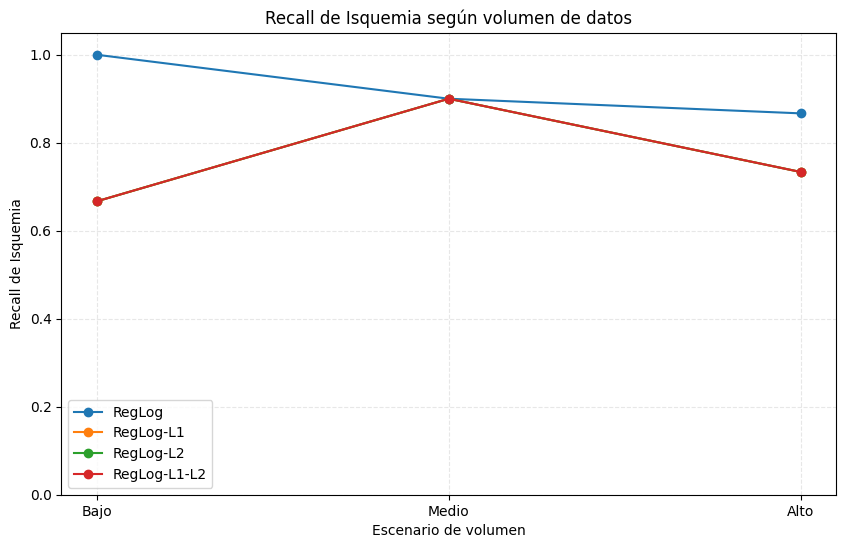

In [27]:
# ==========================================================
# GRÁFICO: RECALL DE ISQUEMIA SEGÚN VOLUMEN
# ==========================================================

plt.figure(figsize=(10, 6))

for modelo in df_volumen["Modelo"].unique():
    subset = df_volumen[df_volumen["Modelo"] == modelo]
    plt.plot(
        subset["Volumen"],
        subset["Recall_Isquemia"],
        marker="o",
        label=modelo
    )

plt.title("Recall de Isquemia según volumen de datos")
plt.xlabel("Escenario de volumen")
plt.ylabel("Recall de Isquemia")
plt.ylim(0, 1.05)
plt.grid(True, linestyle="--", alpha=0.3)
plt.legend()
plt.show()

Grafico de Balanced Accuracy

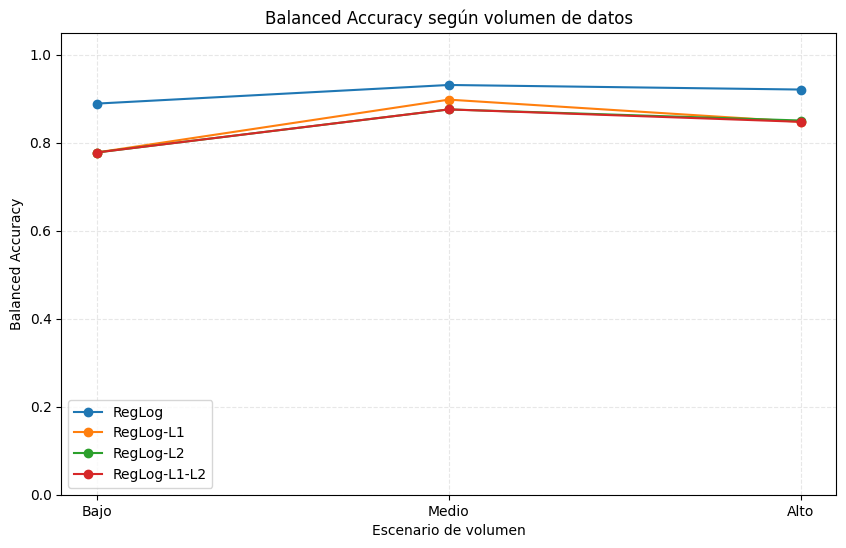

In [28]:
# ==========================================================
# GRÁFICO: BALANCED ACCURACY SEGÚN VOLUMEN
# ==========================================================

plt.figure(figsize=(10, 6))

for modelo in df_volumen["Modelo"].unique():
    subset = df_volumen[df_volumen["Modelo"] == modelo]
    plt.plot(
        subset["Volumen"],
        subset["Balanced_Accuracy"],
        marker="o",
        label=modelo
    )

plt.title("Balanced Accuracy según volumen de datos")
plt.xlabel("Escenario de volumen")
plt.ylabel("Balanced Accuracy")
plt.ylim(0, 1.05)
plt.grid(True, linestyle="--", alpha=0.3)
plt.legend()
plt.show()

2.2.2 Análisis de sensibilidad al solapamiento entre clases

In [29]:
# ==========================================================
# ANÁLISIS DE SENSIBILIDAD AL SOLAPAMIENTO ENTRE CLASES
# ==========================================================

# Definir niveles de solapamiento
niveles_overlap = {
    "Bajo": 0.7,
    "Medio": 1.0,
    "Alto": 1.4
}

# Lista para guardar resultados
resultados_overlap = []

for nombre_overlap, factor in niveles_overlap.items():
    print(f"\nEvaluando nivel de overlap: {nombre_overlap} (factor={factor})")

    # 1. Generar dataset con el overlap correspondiente
    df_temp = generar_dataset_clinico_proporcional(
        n_total=1000,
        seed=42,
        overlap_factor=factor
    )

    # 2. Preparar datos
    X_train_tmp, X_test_tmp, y_train_tmp, y_test_tmp = preparar_datos(df_temp)

    # 3. Crear modelos scratch
    modelos_tmp = {
        "RegLog": LogisticRegressionScratch(
            learning_rate=0.05, epochs=3000, penalty=None
        ),
        "RegLog-L1": LogisticRegressionScratch(
            learning_rate=0.05, epochs=3000, penalty="l1", lambda_reg=0.01
        ),
        "RegLog-L2": LogisticRegressionScratch(
            learning_rate=0.05, epochs=3000, penalty="l2", lambda_reg=0.01
        ),
        "RegLog-L1-L2": LogisticRegressionScratch(
            learning_rate=0.05, epochs=3000, penalty="elastic", lambda_reg=0.01, l1_ratio=0.5
        )
    }

    # 4. Entrenar y evaluar
    for nombre_modelo, modelo in modelos_tmp.items():
        modelo.fit(X_train_tmp, y_train_tmp)
        y_pred_tmp = modelo.predict(X_test_tmp)

        recall_clases = recall_score(y_test_tmp, y_pred_tmp, average=None, labels=[0, 1, 2])

        resultados_overlap.append({
            "Overlap": nombre_overlap,
            "factor_overlap": factor,
            "Modelo": nombre_modelo,
            "Accuracy": accuracy_score(y_test_tmp, y_pred_tmp),
            "Balanced_Accuracy": balanced_accuracy_score(y_test_tmp, y_pred_tmp),
            "Recall_Sano": recall_clases[0],
            "Recall_Riesgo": recall_clases[1],
            "Recall_Isquemia": recall_clases[2],
            "F1_Weighted": f1_score(y_test_tmp, y_pred_tmp, average="weighted"),
            "Costo_Total": costo_total_asimetrico(y_test_tmp, y_pred_tmp, matriz_costos)
        })

# Convertir a DataFrame
df_overlap = pd.DataFrame(resultados_overlap)

print("\nResultados de sensibilidad al solapamiento:")
print(df_overlap.sort_values(by=["Overlap", "Recall_Isquemia"], ascending=[True, False]))


Evaluando nivel de overlap: Bajo (factor=0.7)

Evaluando nivel de overlap: Medio (factor=1.0)

Evaluando nivel de overlap: Alto (factor=1.4)

Resultados de sensibilidad al solapamiento:
   Overlap  factor_overlap        Modelo  Accuracy  Balanced_Accuracy  \
8     Alto             1.4        RegLog     0.945           0.873611   
9     Alto             1.4     RegLog-L1     0.935           0.842361   
10    Alto             1.4     RegLog-L2     0.930           0.831250   
11    Alto             1.4  RegLog-L1-L2     0.935           0.842361   
0     Bajo             0.7        RegLog     0.995           0.997917   
1     Bajo             0.7     RegLog-L1     0.995           0.997917   
2     Bajo             0.7     RegLog-L2     0.990           0.964583   
3     Bajo             0.7  RegLog-L1-L2     0.990           0.964583   
4    Medio             1.0        RegLog     0.975           0.931250   
5    Medio             1.0     RegLog-L1     0.960           0.897917   
6    Medio

graficar Recall de Isquemia según overlap

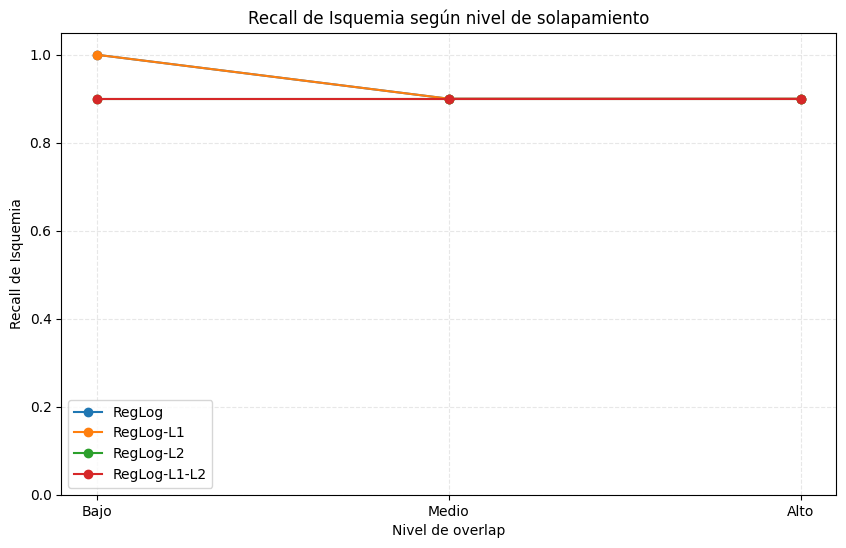

In [30]:
# ==========================================================
# GRÁFICO: RECALL DE ISQUEMIA SEGÚN OVERLAP
# ==========================================================

plt.figure(figsize=(10, 6))

for modelo in df_overlap["Modelo"].unique():
    subset = df_overlap[df_overlap["Modelo"] == modelo]
    plt.plot(
        subset["Overlap"],
        subset["Recall_Isquemia"],
        marker="o",
        label=modelo
    )

plt.title("Recall de Isquemia según nivel de solapamiento")
plt.xlabel("Nivel de overlap")
plt.ylabel("Recall de Isquemia")
plt.ylim(0, 1.05)
plt.grid(True, linestyle="--", alpha=0.3)
plt.legend()
plt.show()

Graficar Balanced Accuracy según overlap

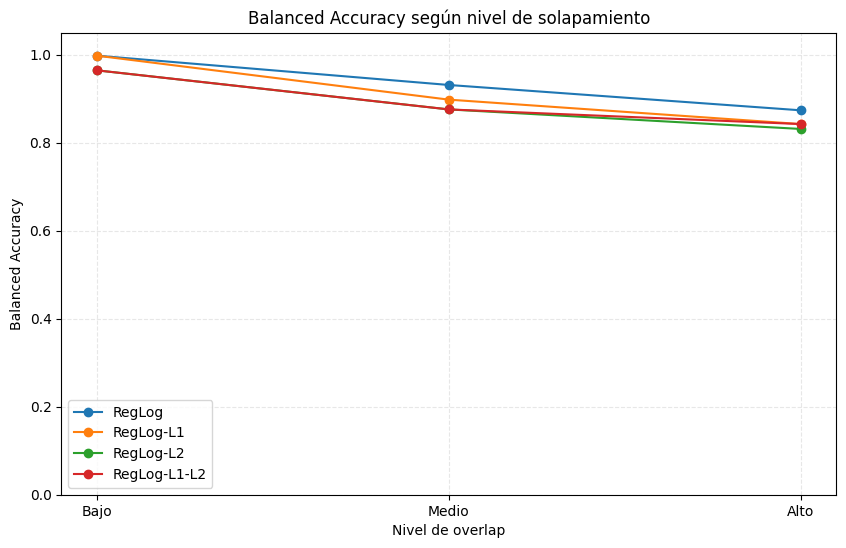

In [31]:
# ==========================================================
# GRÁFICO: BALANCED ACCURACY SEGÚN OVERLAP
# ==========================================================

plt.figure(figsize=(10, 6))

for modelo in df_overlap["Modelo"].unique():
    subset = df_overlap[df_overlap["Modelo"] == modelo]
    plt.plot(
        subset["Overlap"],
        subset["Balanced_Accuracy"],
        marker="o",
        label=modelo
    )

plt.title("Balanced Accuracy según nivel de solapamiento")
plt.xlabel("Nivel de overlap")
plt.ylabel("Balanced Accuracy")
plt.ylim(0, 1.05)
plt.grid(True, linestyle="--", alpha=0.3)
plt.legend()
plt.show()

Graficar costo total segun overlap

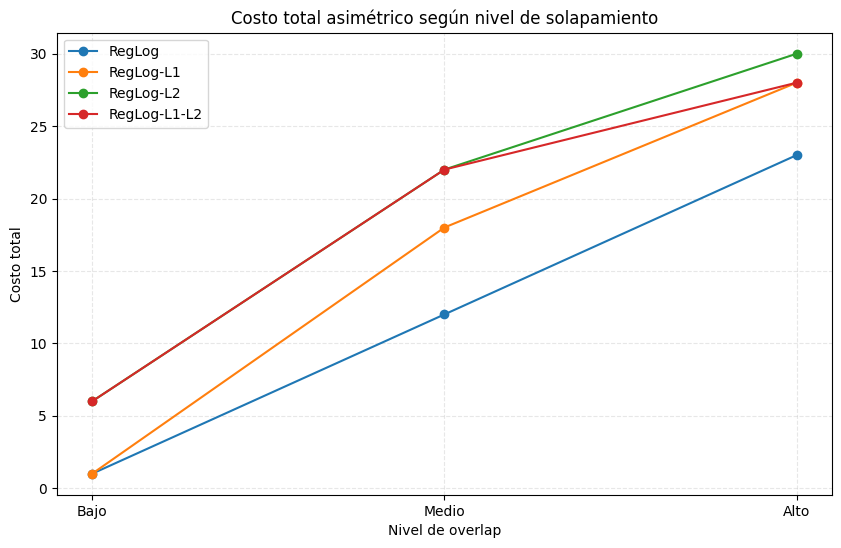

In [32]:
# ==========================================================
# GRÁFICO: COSTO TOTAL SEGÚN OVERLAP
# ==========================================================

plt.figure(figsize=(10, 6))

for modelo in df_overlap["Modelo"].unique():
    subset = df_overlap[df_overlap["Modelo"] == modelo]
    plt.plot(
        subset["Overlap"],
        subset["Costo_Total"],
        marker="o",
        label=modelo
    )

plt.title("Costo total asimétrico según nivel de solapamiento")
plt.xlabel("Nivel de overlap")
plt.ylabel("Costo total")
plt.grid(True, linestyle="--", alpha=0.3)
plt.legend()
plt.show()

## 7. Búsqueda exhaustiva de hiperparámetros y fronteras de decisión

> **Nota metodológica:** esta sección contiene la búsqueda de hiperparámetros y luego la visualización de fronteras de decisión en 2D.

2.3 - Búsqueda de hiperparámetros (grid search)

Grid search para RegLog, L1 y L2

In [33]:
# ==========================================================
# 2.3 GRID SEARCH MANUAL - REGLOG, L1 Y L2
# ==========================================================

learning_rates = [0.01, 0.05, 0.1]
epochs_list = [2000, 3000]
lambda_regs = [0.001, 0.01, 0.1]

resultados_grid = []

# -----------------------------
# 1. Grid para RegLog (sin regularización)
# -----------------------------
for lr in learning_rates:
    for ep in epochs_list:
        modelo = LogisticRegressionScratch(
            learning_rate=lr,
            epochs=ep,
            penalty=None,
            verbose=False
        )

        modelo.fit(X_train_np, y_train)
        y_pred = modelo.predict(X_test_np)

        recall_clases = recall_score(y_test, y_pred, average=None, labels=[0, 1, 2])

        resultados_grid.append({
            "Modelo": "RegLog",
            "learning_rate": lr,
            "epochs": ep,
            "lambda_reg": None,
            "l1_ratio": None,
            "Balanced_Accuracy": balanced_accuracy_score(y_test, y_pred),
            "Recall_Isquemia": recall_clases[2],
            "F1_Weighted": f1_score(y_test, y_pred, average="weighted"),
            "Costo_Total": costo_total_asimetrico(y_test, y_pred, matriz_costos)
        })

# -----------------------------
# 2. Grid para RegLog-L1
# -----------------------------
for lr in learning_rates:
    for ep in epochs_list:
        for lam in lambda_regs:
            modelo = LogisticRegressionScratch(
                learning_rate=lr,
                epochs=ep,
                penalty="l1",
                lambda_reg=lam,
                verbose=False
            )

            modelo.fit(X_train_np, y_train)
            y_pred = modelo.predict(X_test_np)

            recall_clases = recall_score(y_test, y_pred, average=None, labels=[0, 1, 2])

            resultados_grid.append({
                "Modelo": "RegLog-L1",
                "learning_rate": lr,
                "epochs": ep,
                "lambda_reg": lam,
                "l1_ratio": None,
                "Balanced_Accuracy": balanced_accuracy_score(y_test, y_pred),
                "Recall_Isquemia": recall_clases[2],
                "F1_Weighted": f1_score(y_test, y_pred, average="weighted"),
                "Costo_Total": costo_total_asimetrico(y_test, y_pred, matriz_costos)
            })

# -----------------------------
# 3. Grid para RegLog-L2
# -----------------------------
for lr in learning_rates:
    for ep in epochs_list:
        for lam in lambda_regs:
            modelo = LogisticRegressionScratch(
                learning_rate=lr,
                epochs=ep,
                penalty="l2",
                lambda_reg=lam,
                verbose=False
            )

            modelo.fit(X_train_np, y_train)
            y_pred = modelo.predict(X_test_np)

            recall_clases = recall_score(y_test, y_pred, average=None, labels=[0, 1, 2])

            resultados_grid.append({
                "Modelo": "RegLog-L2",
                "learning_rate": lr,
                "epochs": ep,
                "lambda_reg": lam,
                "l1_ratio": None,
                "Balanced_Accuracy": balanced_accuracy_score(y_test, y_pred),
                "Recall_Isquemia": recall_clases[2],
                "F1_Weighted": f1_score(y_test, y_pred, average="weighted"),
                "Costo_Total": costo_total_asimetrico(y_test, y_pred, matriz_costos)
            })

# Convertir a DataFrame
df_grid = pd.DataFrame(resultados_grid)

print("\nResultados grid search (RegLog, L1, L2):")
print(
    df_grid.sort_values(
        by=["Recall_Isquemia", "Balanced_Accuracy", "F1_Weighted", "Costo_Total"],
        ascending=[False, False, False, True]
    ).head(20)
)


Resultados grid search (RegLog, L1, L2):
       Modelo  learning_rate  epochs  lambda_reg l1_ratio  Balanced_Accuracy  \
5      RegLog           0.10    3000         NaN     None           0.942361   
3      RegLog           0.05    3000         NaN     None           0.931250   
4      RegLog           0.10    2000         NaN     None           0.931250   
15  RegLog-L1           0.05    3000       0.001     None           0.931250   
18  RegLog-L1           0.10    2000       0.001     None           0.931250   
21  RegLog-L1           0.10    3000       0.001     None           0.931250   
33  RegLog-L2           0.05    3000       0.001     None           0.931250   
36  RegLog-L2           0.10    2000       0.001     None           0.931250   
39  RegLog-L2           0.10    3000       0.001     None           0.931250   
2      RegLog           0.05    2000         NaN     None           0.920139   
12  RegLog-L1           0.05    2000       0.001     None           0.920139  

Grid search para Elastic Net

In [34]:
# ==========================================================
# 2.3 GRID SEARCH MANUAL - ELASTIC NET
# ==========================================================

l1_ratios = [0.2, 0.5, 0.8]

resultados_grid_elastic = []

for lr in learning_rates:
    for ep in epochs_list:
        for lam in lambda_regs:
            for ratio in l1_ratios:
                modelo = LogisticRegressionScratch(
                    learning_rate=lr,
                    epochs=ep,
                    penalty="elastic",
                    lambda_reg=lam,
                    l1_ratio=ratio,
                    verbose=False
                )

                modelo.fit(X_train_np, y_train)
                y_pred = modelo.predict(X_test_np)

                recall_clases = recall_score(y_test, y_pred, average=None, labels=[0, 1, 2])

                resultados_grid_elastic.append({
                    "Modelo": "RegLog-L1-L2",
                    "learning_rate": lr,
                    "epochs": ep,
                    "lambda_reg": lam,
                    "l1_ratio": ratio,
                    "Balanced_Accuracy": balanced_accuracy_score(y_test, y_pred),
                    "Recall_Isquemia": recall_clases[2],
                    "F1_Weighted": f1_score(y_test, y_pred, average="weighted"),
                    "Costo_Total": costo_total_asimetrico(y_test, y_pred, matriz_costos)
                })

df_grid_elastic = pd.DataFrame(resultados_grid_elastic)

print("\nResultados grid search (Elastic Net):")
print(
    df_grid_elastic.sort_values(
        by=["Recall_Isquemia", "Balanced_Accuracy", "F1_Weighted", "Costo_Total"],
        ascending=[False, False, False, True]
    ).head(20)
)


Resultados grid search (Elastic Net):
          Modelo  learning_rate  epochs  lambda_reg  l1_ratio  \
27  RegLog-L1-L2           0.05    3000       0.001       0.2   
28  RegLog-L1-L2           0.05    3000       0.001       0.5   
29  RegLog-L1-L2           0.05    3000       0.001       0.8   
36  RegLog-L1-L2           0.10    2000       0.001       0.2   
37  RegLog-L1-L2           0.10    2000       0.001       0.5   
38  RegLog-L1-L2           0.10    2000       0.001       0.8   
45  RegLog-L1-L2           0.10    3000       0.001       0.2   
46  RegLog-L1-L2           0.10    3000       0.001       0.5   
47  RegLog-L1-L2           0.10    3000       0.001       0.8   
18  RegLog-L1-L2           0.05    2000       0.001       0.2   
19  RegLog-L1-L2           0.05    2000       0.001       0.5   
20  RegLog-L1-L2           0.05    2000       0.001       0.8   
50  RegLog-L1-L2           0.10    3000       0.010       0.8   
41  RegLog-L1-L2           0.10    2000       0.010

Tabla resumen final del grid search

In [35]:
# ==========================================================
# TABLA GENERAL DE GRID SEARCH
# ==========================================================

df_grid_total = pd.concat([df_grid, df_grid_elastic], ignore_index=True)

print("\nMejores configuraciones del grid search:")
print(
    df_grid_total.sort_values(
        by=["Recall_Isquemia", "Balanced_Accuracy", "F1_Weighted", "Costo_Total"],
        ascending=[False, False, False, True]
    ).head(20)
)


Mejores configuraciones del grid search:
          Modelo  learning_rate  epochs  lambda_reg  l1_ratio  \
5         RegLog           0.10    3000         NaN       NaN   
3         RegLog           0.05    3000         NaN       NaN   
4         RegLog           0.10    2000         NaN       NaN   
15     RegLog-L1           0.05    3000       0.001       NaN   
18     RegLog-L1           0.10    2000       0.001       NaN   
21     RegLog-L1           0.10    3000       0.001       NaN   
33     RegLog-L2           0.05    3000       0.001       NaN   
36     RegLog-L2           0.10    2000       0.001       NaN   
39     RegLog-L2           0.10    3000       0.001       NaN   
69  RegLog-L1-L2           0.05    3000       0.001       0.2   
70  RegLog-L1-L2           0.05    3000       0.001       0.5   
71  RegLog-L1-L2           0.05    3000       0.001       0.8   
78  RegLog-L1-L2           0.10    2000       0.001       0.2   
79  RegLog-L1-L2           0.10    2000       0.

/tmp/ipykernel_5812/155246711.py:5: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_grid_total = pd.concat([df_grid, df_grid_elastic], ignore_index=True)


Elegir la mejor configuración por modelo
Criterio de selección

Como el problema es clínico, vamos a priorizar:

Recall_Isquemia más alto

Balanced_Accuracy más alto

F1_Weighted más alto

Costo_Total más bajo

mejores configuraciones por modelo

In [36]:
# ==========================================================
# MEJORES CONFIGURACIONES POR MODELO
# ==========================================================

# Ordenamos toda la tabla del grid search según prioridad clínica
df_grid_ordenado = df_grid_total.sort_values(
    by=["Recall_Isquemia", "Balanced_Accuracy", "F1_Weighted", "Costo_Total"],
    ascending=[False, False, False, True]
)

# Nos quedamos con la mejor fila de cada modelo
df_mejores_configs = df_grid_ordenado.groupby("Modelo", as_index=False).first()

print("Mejores configuraciones por modelo:")
print(df_mejores_configs)

Mejores configuraciones por modelo:
         Modelo  learning_rate  epochs  lambda_reg  l1_ratio  \
0        RegLog           0.10    3000         NaN       NaN   
1     RegLog-L1           0.05    3000       0.001       NaN   
2  RegLog-L1-L2           0.05    3000       0.001       0.2   
3     RegLog-L2           0.05    3000       0.001       NaN   

   Balanced_Accuracy  Recall_Isquemia  F1_Weighted  Costo_Total  
0           0.942361              0.9     0.979892           10  
1           0.931250              0.9     0.974719           12  
2           0.931250              0.9     0.974719           12  
3           0.931250              0.9     0.974719           12  


Preparar una versión 2D del problema

Ahora entrenaremos modelos solo con:

Troponina_T

Presion_Arterial


Importante

Esto no reemplaza al modelo completo.
Solo sirve para visualización e interpretación.

In [37]:
# ==========================================================
# DATASET REDUCIDO A 2 VARIABLES PARA VISUALIZAR FRONTERAS
# ==========================================================

# Usamos solo dos variables continuas y muy interpretables
X_2d = df[["Troponina_T", "Presion_Arterial"]]
y_2d = df["Clase"].values

# Separar train/test manteniendo proporciones de clases
X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d, y_2d,
    test_size=0.2,
    random_state=42,
    stratify=y_2d
)

# Escalamiento manual usando solo entrenamiento
media_2d = X_train_2d.mean()
std_2d = X_train_2d.std()

X_train_2d = ((X_train_2d - media_2d) / std_2d).values
X_test_2d = ((X_test_2d - media_2d) / std_2d).values

print("Forma de X_train_2d:", X_train_2d.shape)
print("Forma de X_test_2d:", X_test_2d.shape)

Forma de X_train_2d: (800, 2)
Forma de X_test_2d: (200, 2)


Función para entrenar un modelo 2D según la mejor configuración

Vamos a crear una función que lea una fila de df_mejores_configs y entrene el modelo correspondiente.

In [38]:
# ==========================================================
# FUNCIÓN PARA ENTRENAR UN MODELO 2D SEGÚN CONFIGURACIÓN
# ==========================================================

def entrenar_modelo_desde_config(config_row, X_train, y_train):
    """
    Recibe una fila de df_mejores_configs y entrena el modelo correspondiente.
    """
    nombre_modelo = config_row["Modelo"]
    lr = config_row["learning_rate"]
    ep = int(config_row["epochs"])

    # RegLog sin regularización
    if nombre_modelo == "RegLog":
        modelo = LogisticRegressionScratch(
            learning_rate=lr,
            epochs=ep,
            penalty=None,
            verbose=False
        )

    # RegLog con L1
    elif nombre_modelo == "RegLog-L1":
        modelo = LogisticRegressionScratch(
            learning_rate=lr,
            epochs=ep,
            penalty="l1",
            lambda_reg=config_row["lambda_reg"],
            verbose=False
        )

    # RegLog con L2
    elif nombre_modelo == "RegLog-L2":
        modelo = LogisticRegressionScratch(
            learning_rate=lr,
            epochs=ep,
            penalty="l2",
            lambda_reg=config_row["lambda_reg"],
            verbose=False
        )

    # RegLog con Elastic Net
    elif nombre_modelo == "RegLog-L1-L2":
        modelo = LogisticRegressionScratch(
            learning_rate=lr,
            epochs=ep,
            penalty="elastic",
            lambda_reg=config_row["lambda_reg"],
            l1_ratio=config_row["l1_ratio"],
            verbose=False
        )

    else:
        raise ValueError("Modelo no reconocido")

    modelo.fit(X_train, y_train)
    return modelo

Función para graficar la frontera de decisión

In [39]:
# ==========================================================
# FUNCIÓN PARA GRAFICAR FRONTERA DE DECISIÓN EN 2D
# ==========================================================

def graficar_frontera_decision_2d(modelo, X, y, titulo):
    """
    Grafica la frontera de decisión en un problema 2D.
    """

    # Definir límites del plano
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    # Crear malla de puntos
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    # Convertir la malla en lista de puntos
    grid = np.c_[xx.ravel(), yy.ravel()]

    # Predecir clase para cada punto
    Z = modelo.predict(grid)
    Z = Z.reshape(xx.shape)

    # Graficar regiones
    plt.figure(figsize=(9, 7))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdYlGn)

    # Superponer datos reales
    scatter = plt.scatter(
        X[:, 0], X[:, 1],
        c=y,
        cmap=plt.cm.RdYlGn,
        edgecolors="black",
        alpha=0.7
    )

    plt.title(titulo)
    plt.xlabel("Troponina T estandarizada")
    plt.ylabel("Presión arterial estandarizada")
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.show()

Graficar la frontera para cada mejor configuración

Graficando frontera para RegLog...


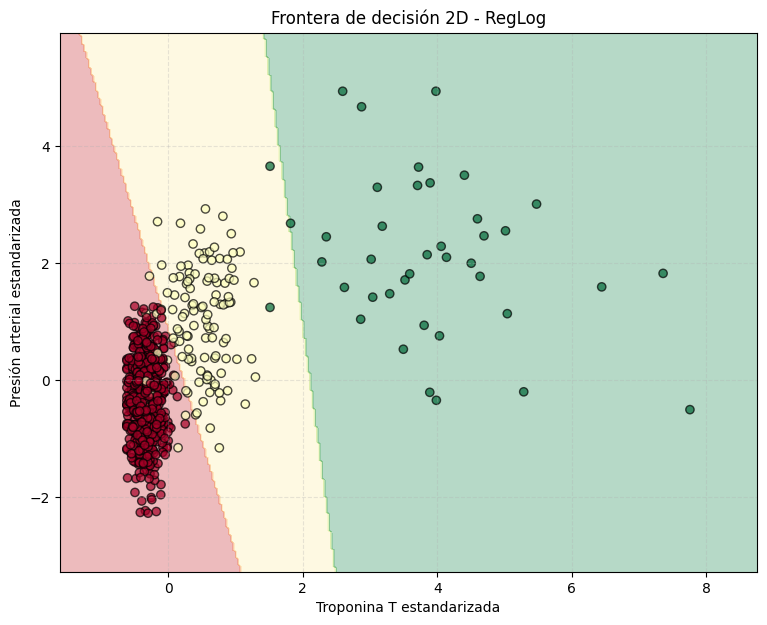

Graficando frontera para RegLog-L1...


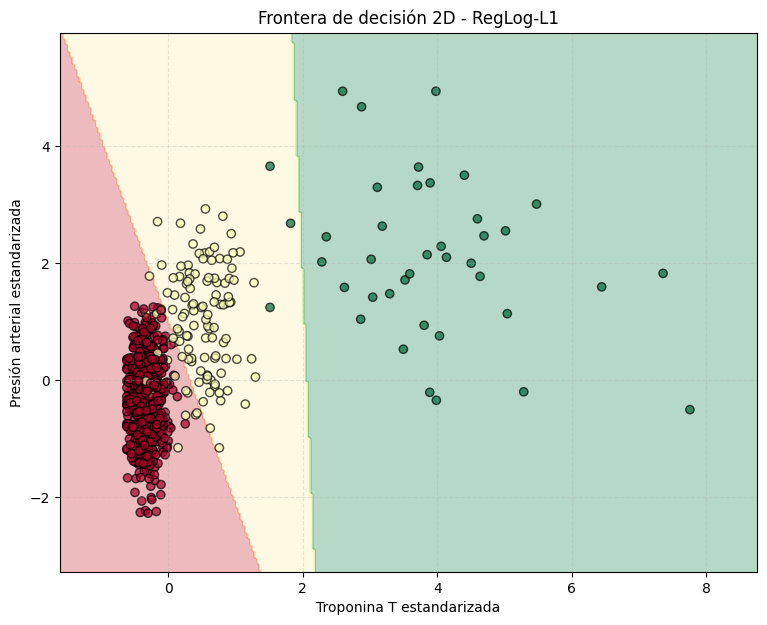

Graficando frontera para RegLog-L1-L2...


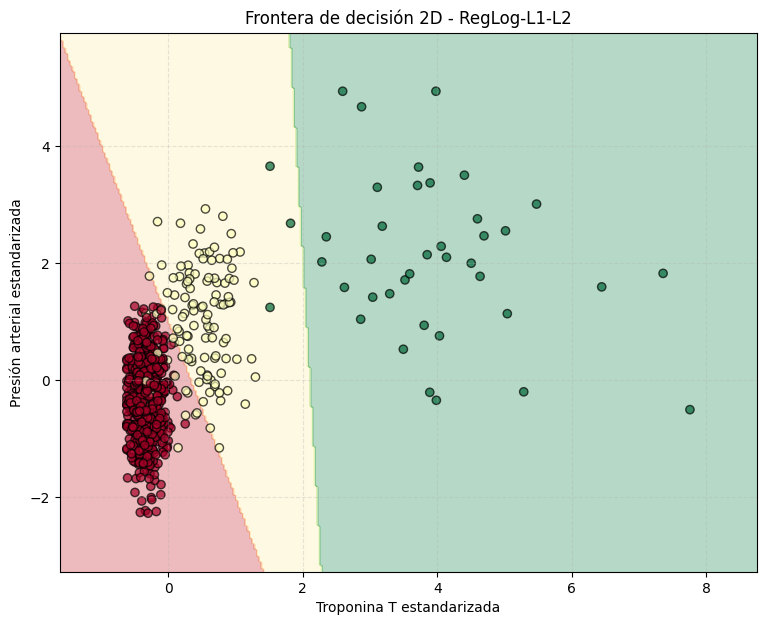

Graficando frontera para RegLog-L2...


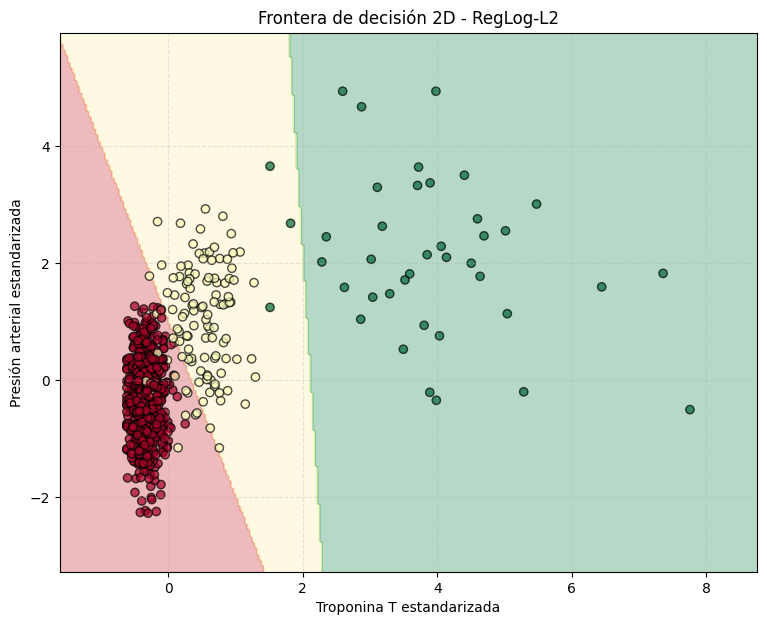

In [40]:
# ==========================================================
# GRAFICAR FRONTERA DE DECISIÓN PARA CADA MEJOR CONFIGURACIÓN
# ==========================================================

for _, fila in df_mejores_configs.iterrows():
    nombre_modelo = fila["Modelo"]

    print(f"Graficando frontera para {nombre_modelo}...")

    modelo_2d = entrenar_modelo_desde_config(fila, X_train_2d, y_train_2d)

    titulo = f"Frontera de decisión 2D - {nombre_modelo}"
    graficar_frontera_decision_2d(modelo_2d, X_train_2d, y_train_2d, titulo)

Tabla resumen final de configuraciones elegidas

In [41]:
# ==========================================================
# TABLA LIMPIA DE MEJORES CONFIGURACIONES
# ==========================================================

columnas_resumen = [
    "Modelo",
    "learning_rate",
    "epochs",
    "lambda_reg",
    "l1_ratio",
    "Balanced_Accuracy",
    "Recall_Isquemia",
    "F1_Weighted",
    "Costo_Total"
]

df_mejores_resumen = df_mejores_configs[columnas_resumen]

print("Resumen final de mejores configuraciones:")
print(df_mejores_resumen)

Resumen final de mejores configuraciones:
         Modelo  learning_rate  epochs  lambda_reg  l1_ratio  \
0        RegLog           0.10    3000         NaN       NaN   
1     RegLog-L1           0.05    3000       0.001       NaN   
2  RegLog-L1-L2           0.05    3000       0.001       0.2   
3     RegLog-L2           0.05    3000       0.001       NaN   

   Balanced_Accuracy  Recall_Isquemia  F1_Weighted  Costo_Total  
0           0.942361              0.9     0.979892           10  
1           0.931250              0.9     0.974719           12  
2           0.931250              0.9     0.974719           12  
3           0.931250              0.9     0.974719           12  


## 8. Compensación del sesgo por clase mayoritaria

Aquí se modifica el Algoritmo 4 para estudiar class weighting y, más adelante, sensibilidad explícita al costo.

# 3. Compensación del sesgo por clase mayoritaria

Función para calcular pesos de clase

In [42]:
# ==========================================================
# FUNCIÓN PARA CALCULAR PESOS DE CLASE
# ==========================================================

def calcular_pesos_clase(y):
    """
    Calcula pesos inversamente proporcionales a la frecuencia de cada clase.

    Fórmula:
        peso_clase = N / (K * n_clase)

    donde:
    - N = número total de muestras
    - K = número de clases
    - n_clase = cantidad de muestras de la clase
    """
    clases, conteos = np.unique(y, return_counts=True)

    N = len(y)
    K = len(clases)

    pesos = {}

    for clase, conteo in zip(clases, conteos):
        pesos[clase] = N / (K * conteo)

    return pesos

revisar los pesos en tu dataset de entrenamiento

In [43]:
# ==========================================================
# VER PESOS DE CLASE EN EL CONJUNTO DE ENTRENAMIENTO
# ==========================================================

pesos_clase = calcular_pesos_clase(y_train)

print("Pesos de clase calculados:")
for clase, peso in pesos_clase.items():
    print(f"Clase {clase}: peso = {peso:.4f}")

Pesos de clase calculados:
Clase 0: peso = 0.4167
Clase 1: peso = 2.2222
Clase 2: peso = 6.6667


Nueva clase del modelo weighted Elastic Net

In [44]:
# ==========================================================
# REGRESIÓN LOGÍSTICA MULTICLASE CON ELASTIC NET + CLASS WEIGHTING
# ==========================================================

class LogisticRegressionScratchWeightedElastic:
    """
    Regresión logística multiclase con:
    - softmax
    - entropía cruzada ponderada por clase
    - regularización Elastic Net

    Este modelo está pensado como modificación del Algoritmo 4 (RegLog-L1-L2).
    """

    def __init__(self, learning_rate=0.05, epochs=3000,
                 lambda_reg=0.01, l1_ratio=0.5, class_weights=None,
                 verbose=False):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.lambda_reg = lambda_reg
        self.l1_ratio = l1_ratio
        self.class_weights = class_weights
        self.verbose = verbose

        self.W = None
        self.loss_history = []
        self.n_classes = None

    def _add_bias(self, X):
        """
        Agrega una columna de 1 para representar el intercepto.
        """
        return np.c_[np.ones((X.shape[0], 1)), X]

    def _one_hot(self, y, n_classes):
        """
        Convierte etiquetas a codificación one-hot.
        """
        Y = np.zeros((len(y), n_classes))
        Y[np.arange(len(y)), y] = 1
        return Y

    def _softmax(self, Z):
        """
        Softmax con estabilidad numérica.
        """
        Z = Z - np.max(Z, axis=1, keepdims=True)
        exp_Z = np.exp(Z)
        return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)

    def _regularization_loss(self):
        """
        Término de regularización Elastic Net.
        No se penaliza el bias.
        """
        W_no_bias = self.W[1:, :]

        l1_part = self.l1_ratio * np.sum(np.abs(W_no_bias))
        l2_part = ((1 - self.l1_ratio) / 2.0) * np.sum(W_no_bias ** 2)

        return self.lambda_reg * (l1_part + l2_part)

    def _regularization_gradient(self):
        """
        Gradiente de Elastic Net.
        """
        grad_reg = np.zeros_like(self.W)
        W_no_bias = self.W[1:, :]

        grad_reg[1:, :] = self.lambda_reg * (
            self.l1_ratio * np.sign(W_no_bias) +
            (1 - self.l1_ratio) * W_no_bias
        )

        return grad_reg

    def fit(self, X, y):
        """
        Entrena el modelo con class weighting.
        """
        Xb = self._add_bias(X)

        n_samples, n_features = Xb.shape
        self.n_classes = len(np.unique(y))

        # Inicialización de pesos
        self.W = np.zeros((n_features, self.n_classes))

        # Etiquetas en one-hot
        Y = self._one_hot(y, self.n_classes)

        # Si no se entregan pesos, se calculan automáticamente
        if self.class_weights is None:
            self.class_weights = calcular_pesos_clase(y)

        # Vector de pesos por ejemplo, según su clase real
        sample_weights = np.array([self.class_weights[clase] for clase in y]).reshape(-1, 1)

        for epoch in range(self.epochs):
            # 1. Puntajes lineales
            logits = Xb @ self.W

            # 2. Probabilidades softmax
            probs = self._softmax(logits)

            # 3. Cross-entropy ponderada
            eps = 1e-12
            log_probs = np.log(probs + eps)

            # Cada ejemplo se multiplica por el peso de su clase
            ce_por_ejemplo = -np.sum(Y * log_probs, axis=1, keepdims=True)
            ce_weighted = np.mean(sample_weights * ce_por_ejemplo)

            # 4. Regularización
            reg_loss = self._regularization_loss()

            # 5. Pérdida total
            loss_total = ce_weighted + reg_loss
            self.loss_history.append(loss_total)

            # 6. Gradiente ponderado de la parte de datos
            grad_data = (Xb.T @ ((probs - Y) * sample_weights)) / n_samples

            # 7. Gradiente de regularización
            grad_reg = self._regularization_gradient()

            # 8. Gradiente total
            grad_total = grad_data + grad_reg

            # 9. Actualización
            self.W -= self.learning_rate * grad_total

            if self.verbose and epoch % 500 == 0:
                print(f"Época {epoch}: loss = {loss_total:.4f}")

    def predict_proba(self, X):
        """
        Devuelve probabilidades por clase.
        """
        Xb = self._add_bias(X)
        logits = Xb @ self.W
        return self._softmax(logits)

    def predict(self, X):
        """
        Devuelve la clase con mayor probabilidad.
        """
        probs = self.predict_proba(X)
        return np.argmax(probs, axis=1)

Entrenar el nuevo modelo ponderado

In [45]:
# ==========================================================
# ENTRENAR REGLOG-L1-L2 CON CLASS WEIGHTING
# ==========================================================

modelo_reglog_elastic_weighted = LogisticRegressionScratchWeightedElastic(
    learning_rate=0.05,
    epochs=3000,
    lambda_reg=0.01,
    l1_ratio=0.5,
    class_weights=pesos_clase,
    verbose=False
)

print("Entrenando RegLog-L1-L2 con class weighting...")
modelo_reglog_elastic_weighted.fit(X_train_np, y_train)

print("Entrenamiento finalizado.")

Entrenando RegLog-L1-L2 con class weighting...
Entrenamiento finalizado.


Evaluacion con las mismas métricas

In [46]:
# ==========================================================
# EVALUAR EL MODELO PONDERADO
# ==========================================================

resultado_weighted = evaluar_modelo_extendido(
    "RegLog-L1-L2-Weighted",
    modelo_reglog_elastic_weighted,
    X_test_np,
    y_test,
    matriz_costos
)

print("\nResultado del modelo ponderado:")
print(resultado_weighted)


Modelo: RegLog-L1-L2-Weighted
Accuracy: 0.9750
Balanced Accuracy: 0.9806
Recall Sano: 0.9750
Recall Riesgo: 0.9667
Recall Isquemia: 1.0000
F1 Weighted: 0.9755
Costo Total Asimétrico: 6

Resultado del modelo ponderado:
{'Modelo': 'RegLog-L1-L2-Weighted', 'Accuracy': 0.975, 'Balanced_Accuracy': np.float64(0.9805555555555555), 'Recall_Sano': np.float64(0.975), 'Recall_Riesgo': np.float64(0.9666666666666667), 'Recall_Isquemia': np.float64(1.0), 'F1_Weighted': 0.9754769415652695, 'Costo_Total': np.int64(6)}


Comparar con el Elastic Net original

In [47]:
# ==========================================================
# COMPARACIÓN DIRECTA: ELASTIC NET ORIGINAL VS PONDERADO
# ==========================================================

modelo_original = modelos_scratch["RegLog-L1-L2"]

resultado_original = evaluar_modelo_extendido(
    "RegLog-L1-L2",
    modelo_original,
    X_test_np,
    y_test,
    matriz_costos
)

comparacion_weighting = pd.DataFrame([
    resultado_original,
    resultado_weighted
])

print("\nComparación entre Elastic Net original y ponderado:")
print(comparacion_weighting)


Modelo: RegLog-L1-L2
Accuracy: 0.9500
Balanced Accuracy: 0.8757
Recall Sano: 0.9938
Recall Riesgo: 0.7333
Recall Isquemia: 0.9000
F1 Weighted: 0.9476
Costo Total Asimétrico: 22

Comparación entre Elastic Net original y ponderado:
                  Modelo  Accuracy  Balanced_Accuracy  Recall_Sano  \
0           RegLog-L1-L2     0.950           0.875694      0.99375   
1  RegLog-L1-L2-Weighted     0.975           0.980556      0.97500   

   Recall_Riesgo  Recall_Isquemia  F1_Weighted  Costo_Total  
0       0.733333              0.9     0.947572           22  
1       0.966667              1.0     0.975477            6  


## 9. Optimización de costos y minimización de errores críticos

# 4. Optimización de costos y minimización de errores críticos

4.1 Definir matriz de costos explícita

In [48]:
# ==========================================================
# MATRIZ DE COSTOS CLÍNICA ASIMÉTRICA
# ==========================================================

# Filas = clase real
# Columnas = clase predicha
# Orden de clases: 0 = Sano, 1 = Riesgo, 2 = Isquemia

matriz_costos_critica = np.array([
    [0, 1, 5],    # real sano
    [2, 0, 10],   # real riesgo
    [50, 8, 0]    # real isquemia
])

print("Matriz de costos clínica:")
print(matriz_costos_critica)

Matriz de costos clínica:
[[ 0  1  5]
 [ 2  0 10]
 [50  8  0]]


derivar pesos por clase desde la matriz de costos

In [49]:
# ==========================================================
# PESOS DE CLASE BASADOS EN COSTO CLÍNICO
# ==========================================================

def pesos_desde_matriz_costos(matriz_costos):
    """
    Asigna a cada clase un peso igual al mayor costo de su fila.
    Esto da más importancia a las clases cuyos errores son más peligrosos.
    """
    pesos = {}

    for clase_real in range(matriz_costos.shape[0]):
        pesos[clase_real] = np.max(matriz_costos[clase_real])

    return pesos


pesos_cost_sensitive = pesos_desde_matriz_costos(matriz_costos_critica)

print("Pesos por clase derivados de la matriz de costos:")
for clase, peso in pesos_cost_sensitive.items():
    print(f"Clase {clase}: peso = {peso}")

Pesos por clase derivados de la matriz de costos:
Clase 0: peso = 5
Clase 1: peso = 10
Clase 2: peso = 50


crear una variante cost-sensitive del Algoritmo 4

In [50]:
# ==========================================================
# REGLOG-L1-L2 COST-SENSITIVE
# ==========================================================

class LogisticRegressionScratchCostSensitive:
    """
    Regresión logística multiclase con:
    - softmax
    - entropía cruzada ponderada por costo clínico
    - regularización Elastic Net
    """

    def __init__(self, learning_rate=0.05, epochs=3000,
                 lambda_reg=0.01, l1_ratio=0.5,
                 class_cost_weights=None,
                 verbose=False):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.lambda_reg = lambda_reg
        self.l1_ratio = l1_ratio
        self.class_cost_weights = class_cost_weights
        self.verbose = verbose

        self.W = None
        self.loss_history = []
        self.n_classes = None

    def _add_bias(self, X):
        return np.c_[np.ones((X.shape[0], 1)), X]

    def _one_hot(self, y, n_classes):
        Y = np.zeros((len(y), n_classes))
        Y[np.arange(len(y)), y] = 1
        return Y

    def _softmax(self, Z):
        Z = Z - np.max(Z, axis=1, keepdims=True)
        exp_Z = np.exp(Z)
        return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)

    def _regularization_loss(self):
        W_no_bias = self.W[1:, :]
        l1_part = self.l1_ratio * np.sum(np.abs(W_no_bias))
        l2_part = ((1 - self.l1_ratio) / 2.0) * np.sum(W_no_bias ** 2)
        return self.lambda_reg * (l1_part + l2_part)

    def _regularization_gradient(self):
        grad_reg = np.zeros_like(self.W)
        W_no_bias = self.W[1:, :]

        grad_reg[1:, :] = self.lambda_reg * (
            self.l1_ratio * np.sign(W_no_bias) +
            (1 - self.l1_ratio) * W_no_bias
        )
        return grad_reg

    def fit(self, X, y):
        Xb = self._add_bias(X)

        n_samples, n_features = Xb.shape
        self.n_classes = len(np.unique(y))

        self.W = np.zeros((n_features, self.n_classes))
        Y = self._one_hot(y, self.n_classes)

        # Si no se entregan pesos, usar 1 para todas las clases
        if self.class_cost_weights is None:
            self.class_cost_weights = {c: 1.0 for c in np.unique(y)}

        # Peso por ejemplo según la clase real
        sample_weights = np.array([self.class_cost_weights[clase] for clase in y]).reshape(-1, 1)

        for epoch in range(self.epochs):
            logits = Xb @ self.W
            probs = self._softmax(logits)

            eps = 1e-12
            log_probs = np.log(probs + eps)

            # Cross-entropy ponderada por costo
            ce_por_ejemplo = -np.sum(Y * log_probs, axis=1, keepdims=True)
            ce_cost_sensitive = np.mean(sample_weights * ce_por_ejemplo)

            reg_loss = self._regularization_loss()

            loss_total = ce_cost_sensitive + reg_loss
            self.loss_history.append(loss_total)

            # Gradiente ponderado
            grad_data = (Xb.T @ ((probs - Y) * sample_weights)) / n_samples
            grad_reg = self._regularization_gradient()
            grad_total = grad_data + grad_reg

            self.W -= self.learning_rate * grad_total

            if self.verbose and epoch % 500 == 0:
                print(f"Época {epoch}: loss = {loss_total:.4f}")

    def predict_proba(self, X):
        Xb = self._add_bias(X)
        logits = Xb @ self.W
        return self._softmax(logits)

    def predict(self, X):
        probs = self.predict_proba(X)
        return np.argmax(probs, axis=1)

Entrenar el modelo cost-sensitive REGLOG-L1-L2

In [51]:
# ==========================================================
# ENTRENAR REGLOG-L1-L2 COST-SENSITIVE
# ==========================================================

modelo_reglog_cost_sensitive = LogisticRegressionScratchCostSensitive(
    learning_rate=0.05,
    epochs=3000,
    lambda_reg=0.01,
    l1_ratio=0.5,
    class_cost_weights=pesos_cost_sensitive,
    verbose=False
)

print("Entrenando RegLog-L1-L2 cost-sensitive...")
modelo_reglog_cost_sensitive.fit(X_train_np, y_train)

print("Entrenamiento finalizado.")

Entrenando RegLog-L1-L2 cost-sensitive...
Entrenamiento finalizado.


Evaluacion del modelo creado

In [52]:
# ==========================================================
# EVALUAR EL MODELO COST-SENSITIVE
# ==========================================================

resultado_cost_sensitive = evaluar_modelo_extendido(
    "RegLog-L1-L2-CostSensitive",
    modelo_reglog_cost_sensitive,
    X_test_np,
    y_test,
    matriz_costos_critica
)

print("\nResultado del modelo cost-sensitive:")
print(resultado_cost_sensitive)


Modelo: RegLog-L1-L2-CostSensitive
Accuracy: 0.9900
Balanced Accuracy: 0.9868
Recall Sano: 0.9938
Recall Riesgo: 0.9667
Recall Isquemia: 1.0000
F1 Weighted: 0.9900
Costo Total Asimétrico: 3

Resultado del modelo cost-sensitive:
{'Modelo': 'RegLog-L1-L2-CostSensitive', 'Accuracy': 0.99, 'Balanced_Accuracy': np.float64(0.9868055555555556), 'Recall_Sano': np.float64(0.99375), 'Recall_Riesgo': np.float64(0.9666666666666667), 'Recall_Isquemia': np.float64(1.0), 'F1_Weighted': 0.99, 'Costo_Total': np.int64(3)}


Bonus : Ajuste de umbrales de decisión (thresholding)

Se realizara una función de predicción basada en costo esperado

In [53]:
# ==========================================================
# PREDICCIÓN COST-SENSITIVE BASADA EN COSTO ESPERADO
# ==========================================================

def predict_cost_sensitive(modelo, X, matriz_costos):
    """
    Predice la clase minimizando el costo esperado en vez de usar argmax.
    """
    probs = modelo.predict_proba(X)   # shape = (n_samples, n_classes)
    n_samples = probs.shape[0]
    n_classes = probs.shape[1]

    y_pred_cost = []

    for i in range(n_samples):
        p = probs[i]  # probabilidades del ejemplo i

        # costo esperado de decidir cada clase j
        costos_esperados = []
        for j in range(n_classes):
            costo_j = np.sum(p * matriz_costos[:, j])
            costos_esperados.append(costo_j)

        clase_elegida = np.argmin(costos_esperados)
        y_pred_cost.append(clase_elegida)

    return np.array(y_pred_cost)

Evaluar el modelo con esta nueva regla de decisión

In [54]:
# ==========================================================
# EVALUAR ELASTIC NET ORIGINAL CON DECISIÓN COST-SENSITIVE
# ==========================================================

modelo_base = modelos_scratch["RegLog-L1-L2"]

y_pred_cost_decision = predict_cost_sensitive(
    modelo_base,
    X_test_np,
    matriz_costos_critica
)

acc_cost_decision = accuracy_score(y_test, y_pred_cost_decision)
bal_acc_cost_decision = balanced_accuracy_score(y_test, y_pred_cost_decision)
recall_clases = recall_score(y_test, y_pred_cost_decision, average=None, labels=[0,1,2])
f1_weighted_cost_decision = f1_score(y_test, y_pred_cost_decision, average="weighted")
costo_total_cost_decision = costo_total_asimetrico(y_test, y_pred_cost_decision, matriz_costos_critica)

print("\nEvaluación con decisión cost-sensitive:")
print(f"Accuracy: {acc_cost_decision:.4f}")
print(f"Balanced Accuracy: {bal_acc_cost_decision:.4f}")
print(f"Recall Sano: {recall_clases[0]:.4f}")
print(f"Recall Riesgo: {recall_clases[1]:.4f}")
print(f"Recall Isquemia: {recall_clases[2]:.4f}")
print(f"F1 Weighted: {f1_weighted_cost_decision:.4f}")
print(f"Costo Total: {costo_total_cost_decision}")


Evaluación con decisión cost-sensitive:
Accuracy: 0.9700
Balanced Accuracy: 0.9472
Recall Sano: 0.9750
Recall Riesgo: 0.9667
Recall Isquemia: 0.9000
F1 Weighted: 0.9707
Costo Total: 14


comparación final entre variantes

comparar las cuatro cosas:

RegLog-L1-L2 original

RegLog-L1-L2-Weighted

RegLog-L1-L2-CostSensitive

RegLog-L1-L2 + decisión cost-sensitive

In [55]:
# ==========================================================
# COMPARACIÓN FINAL DE VARIANTES DEL ALGORITMO 4
# ==========================================================

# Resultado original
resultado_alg4_original = evaluar_modelo_extendido(
    "RegLog-L1-L2",
    modelos_scratch["RegLog-L1-L2"],
    X_test_np,
    y_test,
    matriz_costos_critica
)

# Resultado weighted del punto 3
resultado_alg4_weighted = evaluar_modelo_extendido(
    "RegLog-L1-L2-Weighted",
    modelo_reglog_elastic_weighted,
    X_test_np,
    y_test,
    matriz_costos_critica
)

# Resultado cost-sensitive en aprendizaje
resultado_alg4_cost_sensitive = evaluar_modelo_extendido(
    "RegLog-L1-L2-CostSensitive",
    modelo_reglog_cost_sensitive,
    X_test_np,
    y_test,
    matriz_costos_critica
)

# Resultado con decisión cost-sensitive
resultado_alg4_decision_sensitive = {
    "Modelo": "RegLog-L1-L2-DecisionSensitive",
    "Accuracy": acc_cost_decision,
    "Balanced_Accuracy": bal_acc_cost_decision,
    "Recall_Sano": recall_clases[0],
    "Recall_Riesgo": recall_clases[1],
    "Recall_Isquemia": recall_clases[2],
    "F1_Weighted": f1_weighted_cost_decision,
    "Costo_Total": costo_total_cost_decision
}

df_alg4_comparacion = pd.DataFrame([
    resultado_alg4_original,
    resultado_alg4_weighted,
    resultado_alg4_cost_sensitive,
    resultado_alg4_decision_sensitive
])

print("\nComparación de variantes del Algoritmo 4:")
print(df_alg4_comparacion.sort_values(
    by=["Recall_Isquemia", "Costo_Total"],
    ascending=[False, True]
))


Modelo: RegLog-L1-L2
Accuracy: 0.9500
Balanced Accuracy: 0.8757
Recall Sano: 0.9938
Recall Riesgo: 0.7333
Recall Isquemia: 0.9000
F1 Weighted: 0.9476
Costo Total Asimétrico: 25

Modelo: RegLog-L1-L2-Weighted
Accuracy: 0.9750
Balanced Accuracy: 0.9806
Recall Sano: 0.9750
Recall Riesgo: 0.9667
Recall Isquemia: 1.0000
F1 Weighted: 0.9755
Costo Total Asimétrico: 6

Modelo: RegLog-L1-L2-CostSensitive
Accuracy: 0.9900
Balanced Accuracy: 0.9868
Recall Sano: 0.9938
Recall Riesgo: 0.9667
Recall Isquemia: 1.0000
F1 Weighted: 0.9900
Costo Total Asimétrico: 3

Comparación de variantes del Algoritmo 4:
                           Modelo  Accuracy  Balanced_Accuracy  Recall_Sano  \
2      RegLog-L1-L2-CostSensitive     0.990           0.986806      0.99375   
1           RegLog-L1-L2-Weighted     0.975           0.980556      0.97500   
3  RegLog-L1-L2-DecisionSensitive     0.970           0.947222      0.97500   
0                    RegLog-L1-L2     0.950           0.875694      0.99375   

   Rec

## 10. Importancia de atributos e interpretabilidad

# **5. Análisis de importancia de atributos e interpretabilidad**

Extraer importancia de atributos

In [56]:
# ==========================================================
# ANÁLISIS DE IMPORTANCIA DE ATRIBUTOS
# USANDO REGLOG-L1
# ==========================================================

# Elegimos el modelo más apropiado para selección de características
modelo_importancia = modelos_scratch["RegLog-L1"]

# Nombres de las variables después del preprocesamiento
# Ojo: X_train sigue siendo DataFrame, por eso conserva los nombres de columnas
nombres_variables = X_train.columns.tolist()

# Matriz de pesos del modelo
# La primera fila corresponde al bias, así que la eliminamos
W_sin_bias = modelo_importancia.W[1:, :]   # shape = (n_features, n_classes)

# Calcular importancia global como promedio de magnitudes absolutas por atributo
importancia_global = np.mean(np.abs(W_sin_bias), axis=1)

# Crear DataFrame para ordenar y visualizar mejor
df_importancia = pd.DataFrame({
    "Atributo": nombres_variables,
    "Importancia_Global": importancia_global
})

# Ordenar de mayor a menor importancia
df_importancia = df_importancia.sort_values(by="Importancia_Global", ascending=False)

print("Importancia global de atributos según RegLog-L1:")
print(df_importancia)

Importancia global de atributos según RegLog-L1:
           Atributo  Importancia_Global
0       Troponina_T            1.508198
1  Presion_Arterial            0.392791
5           Dolor_1            0.324602
4              Edad            0.288474
6           Dolor_2            0.000552
7           Dolor_3            0.000397
3          Diabetes            0.000248
8           Dolor_4            0.000190
2     Fibrilacion_V            0.000167


Gráfico de importancia global de atributos

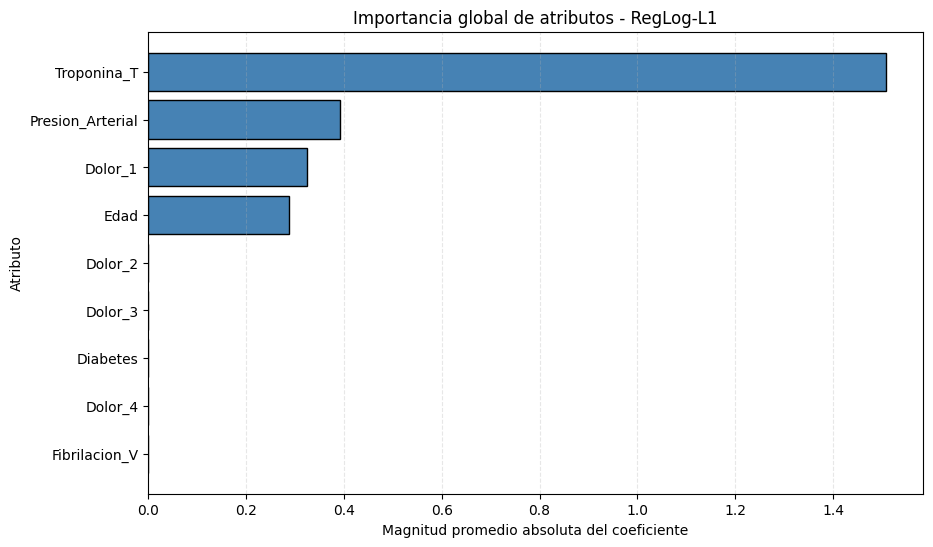

In [57]:
# ==========================================================
# GRÁFICO DE IMPORTANCIA GLOBAL DE ATRIBUTOS
# ==========================================================

plt.figure(figsize=(10, 6))

plt.barh(
    df_importancia["Atributo"],
    df_importancia["Importancia_Global"],
    color="steelblue",
    edgecolor="black"
)

plt.title("Importancia global de atributos - RegLog-L1")
plt.xlabel("Magnitud promedio absoluta del coeficiente")
plt.ylabel("Atributo")
plt.gca().invert_yaxis()  # para que el más importante quede arriba
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.show()

Ver coeficientes por clase

In [58]:
# ==========================================================
# COEFICIENTES POR CLASE
# ==========================================================

df_coeficientes = pd.DataFrame(
    W_sin_bias,
    index=nombres_variables,
    columns=["Clase_Sano", "Clase_Riesgo", "Clase_Isquemia"]
)

print("Coeficientes por clase:")
print(df_coeficientes)

Coeficientes por clase:
                  Clase_Sano  Clase_Riesgo  Clase_Isquemia
Troponina_T        -2.950547      0.000128        1.573919
Presion_Arterial   -1.172937      0.005264        0.000173
Fibrilacion_V      -0.000038     -0.000328       -0.000134
Diabetes            0.000122     -0.000207       -0.000415
Edad               -0.634303      0.230961       -0.000158
Dolor_1             0.956653     -0.017122       -0.000031
Dolor_2            -0.000422      0.000578       -0.000656
Dolor_3            -0.000345      0.000513        0.000333
Dolor_4             0.000321      0.000214       -0.000035


Gráfico por clase

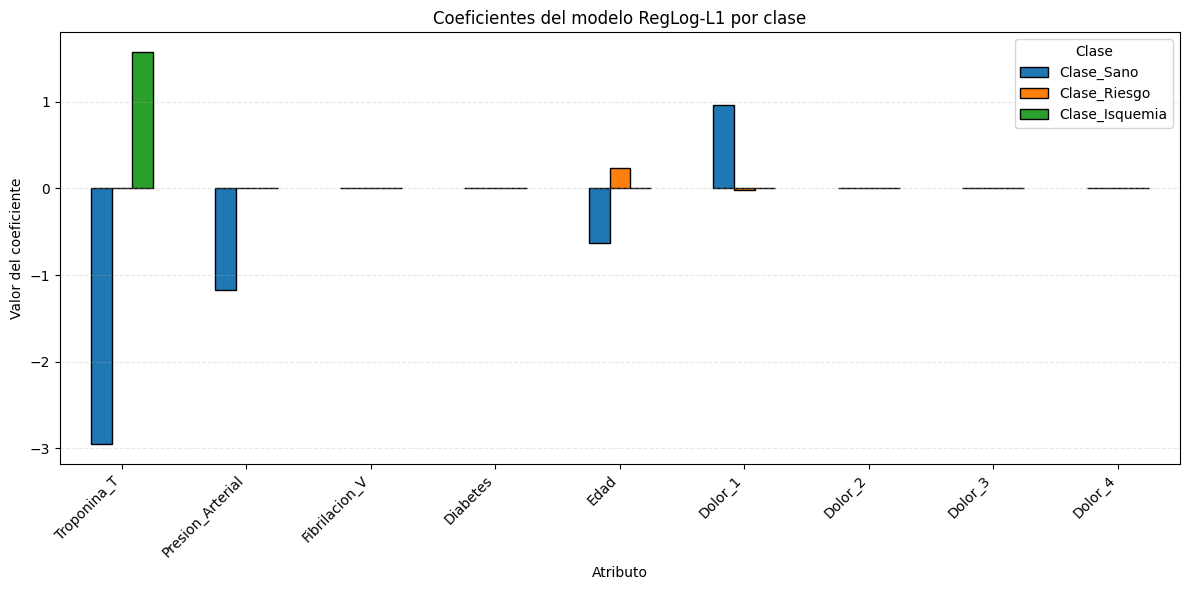

In [59]:
# ==========================================================
# GRÁFICO DE COEFICIENTES POR CLASE
# ==========================================================

df_coeficientes.plot(
    kind="bar",
    figsize=(12, 6),
    edgecolor="black"
)

plt.title("Coeficientes del modelo RegLog-L1 por clase")
plt.xlabel("Atributo")
plt.ylabel("Valor del coeficiente")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.legend(title="Clase")
plt.tight_layout()
plt.show()

Comparar L1 vs Elastic Net

In [60]:
# ==========================================================
# COMPARACIÓN ENTRE REGLOG-L1 Y REGLOG-L1-L2
# ==========================================================

modelo_l1 = modelos_scratch["RegLog-L1"]
modelo_elastic = modelos_scratch["RegLog-L1-L2"]

W_l1 = modelo_l1.W[1:, :]
W_elastic = modelo_elastic.W[1:, :]

importancia_l1 = np.mean(np.abs(W_l1), axis=1)
importancia_elastic = np.mean(np.abs(W_elastic), axis=1)

df_comparacion_importancia = pd.DataFrame({
    "Atributo": nombres_variables,
    "Importancia_L1": importancia_l1,
    "Importancia_ElasticNet": importancia_elastic
}).sort_values(by="Importancia_L1", ascending=False)

print("Comparación de importancia entre L1 y Elastic Net:")
print(df_comparacion_importancia)

Comparación de importancia entre L1 y Elastic Net:
           Atributo  Importancia_L1  Importancia_ElasticNet
0       Troponina_T        1.508198                1.405408
1  Presion_Arterial        0.392791                0.490949
5           Dolor_1        0.324602                0.377212
4              Edad        0.288474                0.318616
6           Dolor_2        0.000552                0.035124
7           Dolor_3        0.000397                0.027394
3          Diabetes        0.000248                0.004460
8           Dolor_4        0.000190                0.000171
2     Fibrilacion_V        0.000167                0.069042


Gráfico comparativo

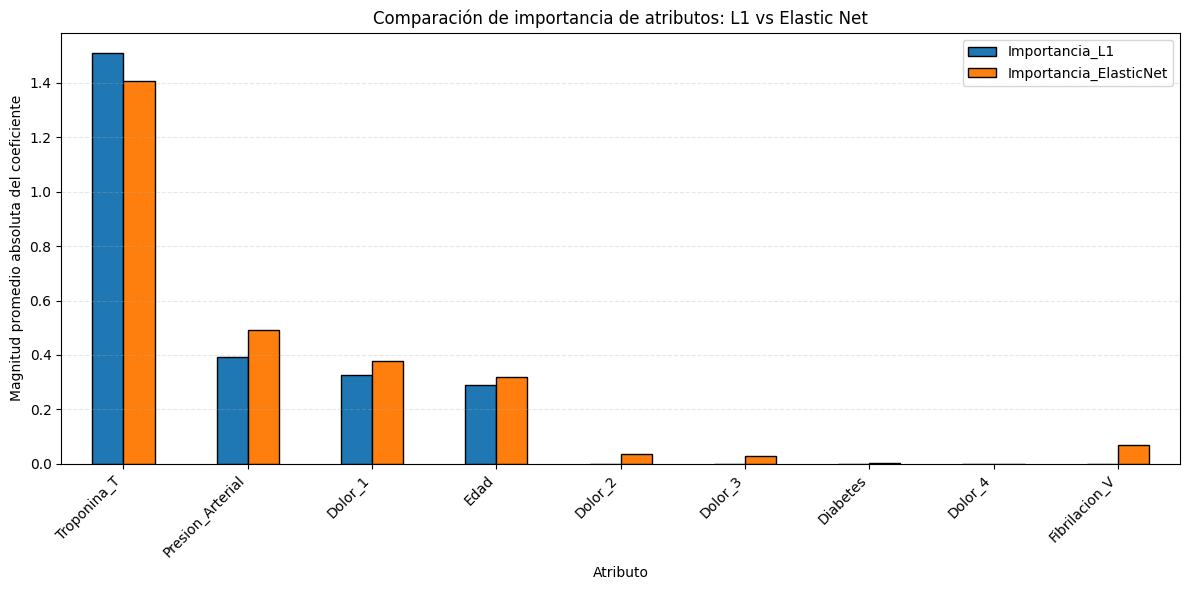

In [61]:
# ==========================================================
# GRÁFICO COMPARATIVO L1 VS ELASTIC NET
# ==========================================================

df_comparacion_importancia_plot = df_comparacion_importancia.set_index("Atributo")

df_comparacion_importancia_plot.plot(
    kind="bar",
    figsize=(12, 6),
    edgecolor="black"
)

plt.title("Comparación de importancia de atributos: L1 vs Elastic Net")
plt.xlabel("Atributo")
plt.ylabel("Magnitud promedio absoluta del coeficiente")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

> **Celda vacía conservada del cuaderno original.** No afecta el resultado, pero se mantiene para preservar la estructura original.

In [62]:
# ==========================================================
# ANÁLISIS ADICIONAL DE FIBRILACION_V
# Frecuencia de Fibrilacion_V por clase
# ==========================================================

tabla_fibrilacion = pd.crosstab(
    df["Clase"],
    df["Fibrilacion_V"],
    normalize="index"
)

print("Proporción de Fibrilacion_V dentro de cada clase:")
print(tabla_fibrilacion)

Proporción de Fibrilacion_V dentro de cada clase:
Fibrilacion_V        0        1
Clase                          
0              0.98875  0.01125
1              0.92000  0.08000
2              0.20000  0.80000


In [63]:
# ==========================================================
# CONTEO ABSOLUTO DE FIBRILACION_V POR CLASE
# ==========================================================

tabla_fibrilacion_abs = pd.crosstab(df["Clase"], df["Fibrilacion_V"])

print("Conteo absoluto de Fibrilacion_V por clase:")
print(tabla_fibrilacion_abs)

Conteo absoluto de Fibrilacion_V por clase:
Fibrilacion_V    0   1
Clase                 
0              791   9
1              138  12
2               10  40


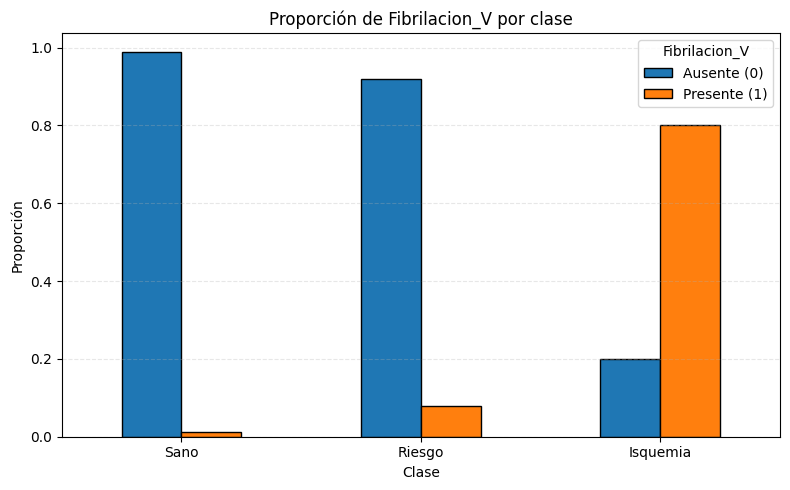

In [64]:
# ==========================================================
# GRÁFICO DE PROPORCIÓN DE FIBRILACION_V POR CLASE
# ==========================================================

tabla_fibrilacion.plot(
    kind="bar",
    figsize=(8, 5),
    edgecolor="black"
)

plt.title("Proporción de Fibrilacion_V por clase")
plt.xlabel("Clase")
plt.ylabel("Proporción")
plt.xticks(ticks=[0, 1, 2], labels=["Sano", "Riesgo", "Isquemia"], rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.legend(title="Fibrilacion_V", labels=["Ausente (0)", "Presente (1)"])
plt.tight_layout()
plt.show()

In [66]:
# ==========================================================
# COMPARACIÓN DE COEFICIENTES CON OTRAS VARIABLES
# ==========================================================

print("Coeficientes de Troponina_T por clase:")
print(df_coeficientes.loc["Troponina_T"])
print()

print("Coeficientes de Presion_Arterial por clase:")
print(df_coeficientes.loc["Presion_Arterial"])
print()

print("Coeficientes de Fibrilacion_V por clase:")
print(df_coeficientes.loc["Fibrilacion_V"])

Coeficientes de Troponina_T por clase:
Clase_Sano       -2.950547
Clase_Riesgo      0.000128
Clase_Isquemia    1.573919
Name: Troponina_T, dtype: float64

Coeficientes de Presion_Arterial por clase:
Clase_Sano       -1.172937
Clase_Riesgo      0.005264
Clase_Isquemia    0.000173
Name: Presion_Arterial, dtype: float64

Coeficientes de Fibrilacion_V por clase:
Clase_Sano       -0.000038
Clase_Riesgo     -0.000328
Clase_Isquemia   -0.000134
Name: Fibrilacion_V, dtype: float64


In [65]:
# ==========================================================
# RESUMEN INTERPRETATIVO DE FIBRILACION_V
# ==========================================================

print("Resumen del análisis de Fibrilacion_V:")
print("- La variable sí fue simulada con una asociación fuerte a la clase Isquemia.")
print("- Sin embargo, en RegLog-L1 sus coeficientes quedaron prácticamente en cero.")
print("- Esto sugiere redundancia frente a variables más dominantes, especialmente Troponina_T.")

Resumen del análisis de Fibrilacion_V:
- La variable sí fue simulada con una asociación fuerte a la clase Isquemia.
- Sin embargo, en RegLog-L1 sus coeficientes quedaron prácticamente en cero.
- Esto sugiere redundancia frente a variables más dominantes, especialmente Troponina_T.
